In [ ]:


import numpy as np 
import os
import pandas as pd
import plotly.express as px
import streamlit as st

In [123]:

import matplotlib.pyplot as plt
import seaborn as sns


In [124]:
data = pd.read_csv('Bacteria_dataset_Multiresictance.csv')
df=data.copy()

In [125]:
df.head()

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA


In [126]:
df.shape

(10710, 27)

In [127]:
df.columns

Index(['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes',
       'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC',
       'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx',
       'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine', 'Collection_Date',
       'Notes'],
      dtype='object')

Added the standard name

In [128]:
df.rename(columns={
    'AMX/AMP': 'Amoxicillin_Ampicillin',
    'AMC': 'Amoxicillin_Clavulanate',
    'CZ': 'Cefazolin',
    'FOX': 'Cefoxitin',
    'CTX/CRO': 'Cefotaxime_Ceftriaxone',
    'IPM': 'Imipenem',
    'GEN': 'Gentamicin',
    'AN': 'Amikacin',
    'Acide nalidixique': 'Nalidixic_Acid',
    'OFX': 'Ofloxacin',
    'ofx': 'Ofloxacin',   # handle lowercase case
    'CIP': 'Ciprofloxacin',
    'C': 'Chloramphenicol',
    'Co-trimoxazole': 'Cotrimoxazole',
    'Furanes': 'Nitrofurantoin',
    'colistine': 'Colistin'
}, inplace=True)

In [129]:
df.columns

Index(['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes',
       'Hypertension', 'Hospital_before', 'Infection_Freq',
       'Amoxicillin_Ampicillin', 'Amoxicillin_Clavulanate', 'Cefazolin',
       'Cefoxitin', 'Cefotaxime_Ceftriaxone', 'Imipenem', 'Gentamicin',
       'Amikacin', 'Nalidixic_Acid', 'Ofloxacin', 'Ciprofloxacin',
       'Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin', 'Colistin',
       'Collection_Date', 'Notes'],
      dtype='object')

In [130]:
# Identify antibiotic columns (all columns in families)
antibiotic_cols = [
    'Amoxicillin_Ampicillin',
    'Amoxicillin_Clavulanate',
    'Cefazolin',
    'Cefoxitin',
    'Cefotaxime_Ceftriaxone',
    'Imipenem',
    'Gentamicin',
    'Amikacin',
    'Nalidixic_Acid',
    'Ofloxacin',
    'Ciprofloxacin',
    'Chloramphenicol',
    'Cotrimoxazole',
    'Nitrofurantoin',
    'Colistin'
]

# Identify risk factors Columns
risk_factors = ["Diabetes", "Hypertension", "Hospital_before", "Infection_Freq"]

#Important Columns 
Important_Columns = ['age/gender', 'Souches',]

#unwanted columns to be deleted
ToDelete=['ID', 'Name', 'Email', 'Address','Collection_Date',
       'Notes']

In [131]:
df[ToDelete]

,ID,Name,Email,Address,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",error,NADA
...,...,...,...,...,...,...
10705,S10995,Mrs. Chelsea Brown MD,mrs..chelsea.brown.md@example.com,"23574 Palmer Lodge, South Aliciaton, GU 00728",2024-12-31,see file
10706,S10996,Mary Kelley,mary.kelley@example.com,"8194 Gonzalez Hill, Loveview, SD 31189",5 Fev 2025,Patient had fever??
10707,S10997,Alexandra Smith,alexandra.smith@example.com,"213 Yates Station, Port Meganstad, PW 17799",08/05/2021,Patient had fever??
10708,S10998,April Cox,april.cox@example.com,"985 Julia Freeway Apt. 753, Dianamouth, SD 07610",05/03/2022,see file


In [132]:
print("===== risk factors Columns summery =====")
for col in risk_factors:
    
    print(f"\n--- Column: {col} ---")
    print(f"Dtype: {df[col].dtype}")
    n_missing = df[col].isna().sum()
    print(f"Missing values: {n_missing} ({round(100 * n_missing / df.shape[0], 2)}%)")

    unique_vals = df[col].nunique(dropna=True)
    print(f"Unique values: {unique_vals} ({round(100 * unique_vals / df.shape[0], 2)}% of rows)")

    if unique_vals <= 10:
        print("Values:", df[col].dropna().unique().tolist())


===== risk factors Columns summery =====

--- Column: Diabetes ---
Dtype: object
Missing values: 635 (5.93%)
Unique values: 4 (0.04% of rows)
Values: ['No', 'True', '?', 'missing']

--- Column: Hypertension ---
Dtype: object
Missing values: 630 (5.88%)
Unique values: 4 (0.04% of rows)
Values: ['No', 'Yes', '?', 'missing']

--- Column: Hospital_before ---
Dtype: object
Missing values: 637 (5.95%)
Unique values: 4 (0.04% of rows)
Values: ['No', 'Yes', '?', 'missing']

--- Column: Infection_Freq ---
Dtype: object
Missing values: 639 (5.97%)
Unique values: 8 (0.07% of rows)
Values: ['0.0', '3.0', '1.0', '2.0', 'unknown', '?', 'error', 'missing']


In [133]:
print("===== Important Columns summery =====")
for col in Important_Columns:
    
    print(f"\n--- Column: {col} ---")
    print(f"Dtype: {df[col].dtype}")
    n_missing = df[col].isna().sum()
    print(f"Missing values: {n_missing} ({round(100 * n_missing / df.shape[0], 2)}%)")

    unique_vals = df[col].nunique(dropna=True)
    print(f"Unique values: {unique_vals} ({round(100 * unique_vals / df.shape[0], 2)}% of rows)")

    if unique_vals <= 10:
        print("Values:", df[col].dropna().unique().tolist())

===== Important Columns summery =====

--- Column: age/gender ---
Dtype: object
Missing values: 621 (5.8%)
Unique values: 184 (1.72% of rows)

--- Column: Souches ---
Dtype: object
Missing values: 640 (5.98%)
Unique values: 9298 (86.82% of rows)


In [134]:
# ===== Fused Antibiotics Summary =====
print("\n===== FUSED ANTIBIOTICS SUMMARY =====")
# Stack all antibiotic values into a single series
all_ab_values = df[antibiotic_cols].stack()
counts = all_ab_values.value_counts(dropna=False)
percentages = round(100 * counts / len(all_ab_values), 2)

# Print fused statistics
print("\nCounts of R/S/I/other/NaN across all antibiotics:")
print(counts)
print("\nPercentages:")
print(percentages)

# Optional: most common resistance
most_common = counts.idxmax()
print(f"\nMost frequent value across all antibiotics: {most_common}")


===== FUSED ANTIBIOTICS SUMMARY =====

Counts of R/S/I/other/NaN across all antibiotics:
S               97298
R               46627
s                1449
Intermediate     1337
i                1335
r                1309
?                 920
missing           889
Name: count, dtype: int64

Percentages:
S               64.37
R               30.85
s                0.96
Intermediate     0.88
i                0.88
r                0.87
?                0.61
missing          0.59
Name: count, dtype: float64

Most frequent value across all antibiotics: S


# 🔬 Preprocessing Phase

In [135]:
df =df[Important_Columns+risk_factors+antibiotic_cols]
df.head()

,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,Amoxicillin_Ampicillin,Amoxicillin_Clavulanate,Cefazolin,Cefoxitin,...,Imipenem,Gentamicin,Amikacin,Nalidixic_Acid,Ofloxacin,Ciprofloxacin,Chloramphenicol,Cotrimoxazole,Nitrofurantoin,Colistin
0,37/F,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,...,R,S,S,S,S,S,R,S,S,S
1,29/F,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,...,R,S,S,S,S,S,S,S,S,S
2,77/F,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,...,S,S,S,S,S,R,R,S,S,S
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13/F,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,...,R,R,R,S,S,S,S,S,S,S


Step 1: Clean Species Names (`Souches`)
We remove unnecessary strain IDs (e.g., `S290 Escherichia coli`) and keep only the species name (`Escherichia coli`).  
We also move `Souches` to the first column for clarity.


In [136]:
# --- Keep only species name in Souches ---
if "Souches" in df.columns:
    # Remove leading strain ID (like S290) and keep the species
    df["Souches"] = df["Souches"].astype(str).apply(lambda x: " ".join(x.split()[1:]) if len(x.split())>1 else x)

species_corrections = {
    # --- Escherichia coli ---
    "E.coi": "Escherichia coli",
    "E.cli": "Escherichia coli",
    "E.coli": "Escherichia coli",
    "E. coli": "Escherichia coli",

    # --- Proteus mirabilis ---
    "Proteus mirabilis": "Proteus mirabilis",
    "Protus mirabilis": "Proteus mirabilis",
    "Proeus mirabilis": "Proteus mirabilis",
    "Prteus mirabilis": "Proteus mirabilis",
    "Prot0.eus mirabilis": "Proteus mirabilis",
    "Prot.eus mirabilis": "Proteus mirabilis",

    # --- Klebsiella pneumoniae ---
    "Klebsiella pneumoniae": "Klebsiella pneumoniae",
    "Klbsiella pneumoniae": "Klebsiella pneumoniae",
    "Klebsie.lla pneumoniae": "Klebsiella pneumoniae",

    # --- Enterobacteria spp. ---
    "Enterobacteria spp.": "Enterobacteria spp.",
    "Enteobacteria spp.": "Enterobacteria spp.",
    "Enter.bacteria spp.": "Enterobacteria spp.",
    "Entero.bacteria spp.": "Enterobacteria spp.",

    # --- Citrobacter spp. ---
    "Citrobacter spp.": "Citrobacter spp.",
    "Citrobacteria spp.": "Citrobacter spp.",
    "Citro.bacter spp.": "Citrobacter spp.",

    # --- Serratia marcescens ---
    "Serratia marcescens": "Serratia marcescens",
    "Seratia marcescens": "Serratia marcescens",
    "Serratia marcesens": "Serratia marcescens",
    "Serratia marcecens": "Serratia marcescens",

    # --- Morganella morganii ---
    "Morganella morganii": "Morganella morganii",
    "Morganiella morganii": "Morganella morganii",
    "Morganela morganii": "Morganella morganii",
    "Morganella morgani": "Morganella morganii",

    # --- Pseudomonas aeruginosa ---
    "Pseudomonas aeruginosa": "Pseudomonas aeruginosa",
    "Pseudomona aeruginosa": "Pseudomonas aeruginosa",
    "Psudomonas aeruginosa": "Pseudomonas aeruginosa",
    "Pseudomonas aeruginosaa": "Pseudomonas aeruginosa",

    # --- Acinetobacter baumannii ---
    "Acinetobacter baumannii": "Acinetobacter baumannii",
    "Acinetobcter baumannii": "Acinetobacter baumannii",
    "Acinetobacter baumanii": "Acinetobacter baumannii",
    "Acinetobactr baumannii": "Acinetobacter baumannii"
}

# Apply corrections
df["Souches"] = df["Souches"].replace(species_corrections)
df.head()

,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,Amoxicillin_Ampicillin,Amoxicillin_Clavulanate,Cefazolin,Cefoxitin,...,Imipenem,Gentamicin,Amikacin,Nalidixic_Acid,Ofloxacin,Ciprofloxacin,Chloramphenicol,Cotrimoxazole,Nitrofurantoin,Colistin
0,37/F,Escherichia coli,No,No,No,0.0,R,R,R,R,...,R,S,S,S,S,S,R,S,S,S
1,29/F,Morganella morganii,True,No,No,3.0,S,R,S,R,...,R,S,S,S,S,S,S,S,S,S
2,77/F,Proteus mirabilis,True,No,No,3.0,S,R,S,R,...,S,S,S,S,S,R,R,S,S,S
3,NaN,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13/F,Escherichia coli,No,Yes,No,1.0,S,S,R,R,...,R,R,R,S,S,S,S,S,S,S


 Standardize Risk Factor Columns
Risk factor columns (`Diabetes`, `Hypertension`, `Hospital_before`) often contain inconsistent labels.  
We normalize all values into:
- `"Yes"`
- `"No"`
- `NaN` (for missing/invalid entries).


In [137]:
# --- Standardize categorical columns ---
def standardize_yes_no(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()
    if val in ["yes", "y", "true", "1"]:
        return "Yes"
    elif val in ["no", "n", "false", "0"]:
        return "No"
    elif val in ["?", "missing", "none"]:
        return np.nan
    return val

for col in ["Diabetes", "Hypertension", "Hospital_before"]:
    if col in df.columns:
        df[col] = df[col].apply(standardize_yes_no)

In [138]:
# --- Infection_Freq standardization ---
freq_map = {
    0.0: 0,
    1.0: 1,
    2.0: 2,
    3.0: 3,
    "0.0": 0,
    "1.0": 1,
    "2.0": 2,
    "3.0": 3,
    "unknown": np.nan,
    "error": np.nan,
    "?": np.nan,
    "missing": np.nan
}

df['Infection_Freq'] = df['Infection_Freq'].map(freq_map)


df['Infection_Freq'] = df['Infection_Freq'].map(freq_map)
df['Infection_Freq'] = pd.to_numeric(df['Infection_Freq'], errors="coerce")
df['Infection_Freq'].value_counts(dropna=False)
df.head()

,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,Amoxicillin_Ampicillin,Amoxicillin_Clavulanate,Cefazolin,Cefoxitin,...,Imipenem,Gentamicin,Amikacin,Nalidixic_Acid,Ofloxacin,Ciprofloxacin,Chloramphenicol,Cotrimoxazole,Nitrofurantoin,Colistin
0,37/F,Escherichia coli,No,No,No,0.0,R,R,R,R,...,R,S,S,S,S,S,R,S,S,S
1,29/F,Morganella morganii,Yes,No,No,3.0,S,R,S,R,...,R,S,S,S,S,S,S,S,S,S
2,77/F,Proteus mirabilis,Yes,No,No,3.0,S,R,S,R,...,S,S,S,S,S,R,R,S,S,S
3,NaN,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13/F,Escherichia coli,No,Yes,No,1.0,S,S,R,R,...,R,R,R,S,S,S,S,S,S,S


Split Age and Gender
The column `age/gender` is split into two separate fields:
- `Age` → numeric  
- `Gender` → standardized to `"M"` or `"F"`

This step ensures better handling of demographic data.


In [139]:
# --- Split age/gender ---
df[["Age","Gender"]] = df["age/gender"].str.split("/", expand=True)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Gender"] = df["Gender"].str.upper().map({"F":"F","M":"M","MALE":"M","FEMALE":"F"})
df.head()


,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,Amoxicillin_Ampicillin,Amoxicillin_Clavulanate,Cefazolin,Cefoxitin,...,Amikacin,Nalidixic_Acid,Ofloxacin,Ciprofloxacin,Chloramphenicol,Cotrimoxazole,Nitrofurantoin,Colistin,Age,Gender
0,37/F,Escherichia coli,No,No,No,0.0,R,R,R,R,...,S,S,S,S,R,S,S,S,37.0,F
1,29/F,Morganella morganii,Yes,No,No,3.0,S,R,S,R,...,S,S,S,S,S,S,S,S,29.0,F
2,77/F,Proteus mirabilis,Yes,No,No,3.0,S,R,S,R,...,S,S,S,R,R,S,S,S,77.0,F
3,NaN,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13/F,Escherichia coli,No,Yes,No,1.0,S,S,R,R,...,R,S,S,S,S,S,S,S,13.0,F



- `Newborn` (0–2 years)  
- `Child` (3–12)  
- `Teenager` (13–19)  
- `Young Adult` (20–35)  
- `Senior Adult` (36–50)  
- `Senior` (51+)  


In [140]:
# --- Age category ---
def age_category(age):
    if pd.isna(age):
        return np.nan
    age = float(age)
    if 0 <= age <= 2:
        return "Newborn"
    elif 2 < age <= 12:
        return "Child"
    elif 13 <= age <= 19:
        return "Teenager"
    elif 20 <= age <= 35:
        return "Young Adult"
    elif 36 <= age <= 50:
        return "Senior Adult"
    elif age >= 51:
        return "Senior"
    return np.nan

df["AgeCategory"] = df["Age"].apply(age_category)

 Standardize Antibiotic Test Results
Antibiotic columns contain inconsistent values (`s`, `r`, `"Resistant"`, `"Sensitive"`, `"Intermediate"`).  
We normalize everything into:
- `"R"` = Resistant  
- `"S"` = Susceptible  
- `"I"` = Intermediate  
- `NaN` = missing/invalid  


In [141]:
# --- Clean antibiotic values ---
antibiotic_cols = [
    'Amoxicillin_Ampicillin',
    'Amoxicillin_Clavulanate',
    'Cefazolin',
    'Cefoxitin',
    'Cefotaxime_Ceftriaxone',
    'Imipenem',
    'Gentamicin',
    'Amikacin',
    'Nalidixic_Acid',
    'Ofloxacin',
    'Ciprofloxacin',
    'Chloramphenicol',
    'Cotrimoxazole',
    'Nitrofurantoin',
    'Colistin'
]
def standardize_ab(val):
    if pd.isna(val):
        return np.nan
    val = str(val).upper()
    if val in ["R","RESISTANT"]:
        return "R"
    elif val in ["S","SENSITIVE"]:
        return "S"
    elif val in ["I","INTERMEDIATE"]:
        return "I"
    return np.nan

for col in antibiotic_cols:
    df[col] = df[col].apply(standardize_ab)

 Drop Unneeded Columns
We remove columns that are not useful for analysis:
such as data, name , notes etc

- `age/gender` (already split into Age + Gender)  



In [142]:
# --- Drop unneeded columns ---
drop_cols = ["age/gender"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

Remove Remaining Missing Rows
For this stage, we drop any rows with missing values across all columns.  
(Depending on the analysis, imputation methods could also be applied instead of deletion.)



In [143]:
df.isna().sum()

Souches                      0
Diabetes                   763
Hypertension               763
Hospital_before            763
Infection_Freq             996
Amoxicillin_Ampicillin     753
Amoxicillin_Clavulanate    753
Cefazolin                  753
Cefoxitin                  753
Cefotaxime_Ceftriaxone     753
Imipenem                   753
Gentamicin                 753
Amikacin                   753
Nalidixic_Acid             753
Ofloxacin                  753
Ciprofloxacin              753
Chloramphenicol            753
Cotrimoxazole              753
Nitrofurantoin             753
Colistin                   753
Age                        763
Gender                     763
AgeCategory                763
dtype: int64

In [144]:
nan_counts = df.isna().sum(axis =1)
nan_groups = nan_counts.value_counts().sort_index()
nan_groups

0     9714
1      233
7       10
22     753
Name: count, dtype: int64

In [145]:
df = df[df.isna().sum(axis=1) <= 3 ]

In [146]:
df.isna().sum()

Souches                      0
Diabetes                     0
Hypertension                 0
Hospital_before              0
Infection_Freq             233
Amoxicillin_Ampicillin       0
Amoxicillin_Clavulanate      0
Cefazolin                    0
Cefoxitin                    0
Cefotaxime_Ceftriaxone       0
Imipenem                     0
Gentamicin                   0
Amikacin                     0
Nalidixic_Acid               0
Ofloxacin                    0
Ciprofloxacin                0
Chloramphenicol              0
Cotrimoxazole                0
Nitrofurantoin               0
Colistin                     0
Age                          0
Gender                       0
AgeCategory                  0
dtype: int64

In [147]:
df['Infection_Freq'].value_counts(dropna=False)

Infection_Freq
2.0    2966
1.0    2889
3.0    1963
0.0    1896
NaN     233
Name: count, dtype: int64

#missing completely at random (MCAR) if the missingness is independent of both observed and unobserved data.

In [148]:
def group_missing_by_column(df, col="Infection_Freq"):
    results = {}

    for group_col in df.columns:
        if col == group_col:
            continue
        
        res = df.groupby(group_col)[col].apply(lambda x: x.isna().mean())
        results[group_col] = res

    print(results)
group_missing_by_column(df, col="Infection_Freq")





{'Souches': Souches
Acinetobacter baumannii    0.022099
Citrobacter spp.           0.027027
Enterobacteria spp.        0.027081
Escherichia coli           0.022029
Klebsiella pneumoniae      0.011396
Morganella morganii        0.042623
Proteus mirabilis          0.030997
Pseudomonas aeruginosa     0.015000
Serratia marcescens        0.031250
Name: Infection_Freq, dtype: float64, 'Diabetes': Diabetes
No     0.022327
Yes    0.027616
Name: Infection_Freq, dtype: float64, 'Hypertension': Hypertension
No     0.022624
Yes    0.025838
Name: Infection_Freq, dtype: float64, 'Hospital_before': Hospital_before
No     0.023830
Yes    0.022457
Name: Infection_Freq, dtype: float64, 'Amoxicillin_Ampicillin': Amoxicillin_Ampicillin
I    0.005495
R    0.021895
S    0.026381
Name: Infection_Freq, dtype: float64, 'Amoxicillin_Clavulanate': Amoxicillin_Clavulanate
I    0.011976
R    0.023236
S    0.024181
Name: Infection_Freq, dtype: float64, 'Cefazolin': Cefazolin
I    0.006061
R    0.023554
S    0.02394

nan filled with median that is 2

In [149]:
med = df['Infection_Freq'].median()
df.isna().sum()
float(med)
df['Infection_Freq'] = df['Infection_Freq'].fillna(med)
df

,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,Amoxicillin_Ampicillin,Amoxicillin_Clavulanate,Cefazolin,Cefoxitin,Cefotaxime_Ceftriaxone,...,Nalidixic_Acid,Ofloxacin,Ciprofloxacin,Chloramphenicol,Cotrimoxazole,Nitrofurantoin,Colistin,Age,Gender,AgeCategory
0,Escherichia coli,No,No,No,0.0,R,R,R,R,R,...,S,S,S,R,S,S,S,37.0,F,Senior Adult
1,Morganella morganii,Yes,No,No,3.0,S,R,S,R,S,...,S,S,S,S,S,S,S,29.0,F,Young Adult
2,Proteus mirabilis,Yes,No,No,3.0,S,R,S,R,S,...,S,S,R,R,S,S,S,77.0,F,Senior
4,Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,...,S,S,S,S,S,S,S,13.0,F,Teenager
5,Escherichia coli,Yes,No,No,3.0,R,S,R,R,S,...,S,S,S,S,S,S,S,57.0,M,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10704,Escherichia coli,No,No,No,0.0,S,R,R,R,S,...,R,S,S,R,S,S,S,43.0,F,Senior Adult
10705,Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,...,S,S,S,S,S,S,S,17.0,M,Teenager
10706,Proteus mirabilis,Yes,No,Yes,3.0,S,R,S,S,S,...,S,S,S,S,S,S,S,20.0,F,Young Adult
10707,Escherichia coli,No,No,No,0.0,R,R,S,R,R,...,S,R,S,R,S,S,S,33.0,M,Young Adult


In [150]:
df.isna().sum()
df.to_csv("cleaned_antibiotic_resistance_dataset.csv", index=False)

In [151]:
# --- Print unique values per column (fuse antibiotics) ---
#Important Columns 
Important_Columns = ['Age','Gender', 'Souches',]
print("===== UNIQUE VALUES PER COLUMN =====")
for col in Important_Columns+risk_factors:
    unique_vals = df[col].dropna().unique()
    print(f"\n--- {col} ---")
    print(unique_vals)

# --- Fused antibiotics unique values ---
all_ab_values = df[antibiotic_cols].stack()
print("\n===== FUSED ANTIBIOTICS UNIQUE VALUES =====")
print(all_ab_values.dropna().unique())

===== UNIQUE VALUES PER COLUMN =====

--- Age ---
[37. 29. 77. 13. 57. 68. 18. 36. 49. 47. 74. 27. 34. 19. 38. 71. 54. 73.
 66. 50. 52. 88. 80. 16. 86. 17. 76. 79. 20. 28. 51. 35.  2. 58. 22. 39.
 87. 42. 61. 65. 31.  0. 69. 26. 23. 85. 24. 44. 40. 53.  4. 63. 48. 45.
  6. 56.  1. 15. 60. 43. 64.  8. 70. 62. 10. 46. 82. 12. 41. 78. 33. 67.
 30. 59. 90. 84. 14. 32. 83. 81. 72.  9. 21. 75.  5. 55.  3. 25.  7. 11.
 89.]

--- Gender ---
['F' 'M']

--- Souches ---
['Escherichia coli' 'Morganella morganii' 'Proteus mirabilis'
 'Citrobacter spp.' 'Enterobacteria spp.' 'Pseudomonas aeruginosa'
 'Klebsiella pneumoniae' 'Serratia marcescens' 'Acinetobacter baumannii']

--- Diabetes ---
['No' 'Yes']

--- Hypertension ---
['No' 'Yes']

--- Hospital_before ---
['No' 'Yes']

--- Infection_Freq ---
[0. 3. 1. 2.]

===== FUSED ANTIBIOTICS UNIQUE VALUES =====
['R' 'S' 'I']


Sorted according to their family Imipenem belongs to Beta lactams , but added as  different family as it is last line drug also sub family carbapenems


In [152]:

families = {
    "Beta_lactams": [
        'Amoxicillin_Ampicillin',
        'Amoxicillin_Clavulanate',
        'Cefazolin',
        'Cefoxitin',
        'Cefotaxime_Ceftriaxone'
    ],
    
    "Carbapenems": [
        'Imipenem'
    ],
    
    "Aminoglycosides": [
        'Gentamicin',
        'Amikacin'
    ],
    
    "Fluoroquinolones": [
        'Nalidixic_Acid',
        'Ofloxacin',
        'Ciprofloxacin'
    ],
    
    "Phenicols": [
        'Chloramphenicol'
    ],
    
    "Folate_pathway_inhibitors": [
        'Cotrimoxazole'
    ],
    
    "Nitrofurans": [
        'Nitrofurantoin'
    ],
    
    "Polymyxins": [
        'Colistin'
    ]
}

def count_resistant_families(row):
    resistant_families = 0
    for family, cols in families.items():
        for col in cols:
            val = str(row.get(col, "")).strip().upper()
            if val == "R":
                resistant_families += 1
                break  # stop after first resistance in this family
    return resistant_families
df["MultiResistance"] = df.apply(lambda row: count_resistant_families(row), axis=1)
df['MultiResistance'].value_counts()

MultiResistance
3    2851
2    2761
4    1741
1    1444
5     704
0     222
6     188
7      34
8       2
Name: count, dtype: int64

In [153]:
df.shape

(9947, 24)

In [154]:
# Identify antibiotic columns (all columns in families)
antibiotic_cols = [
    'Amoxicillin_Ampicillin',
    'Amoxicillin_Clavulanate',
    'Cefazolin',
    'Cefoxitin',
    'Cefotaxime_Ceftriaxone',
    'Imipenem',
    'Gentamicin',
    'Amikacin',
    'Nalidixic_Acid',
    'Ofloxacin',
    'Ciprofloxacin',
    'Chloramphenicol',
    'Cotrimoxazole',
    'Nitrofurantoin',
    'Colistin'
]
# Identify risk factors Columns
risk_factors = ["Diabetes", "Hypertension", "Hospital_before", "Infection_Freq"]

#Important Columns 
Important_Columns = ['Souches','Age','Gender',	'AgeCategory',	'MultiResistance']

In [155]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x600 with 0 Axes>

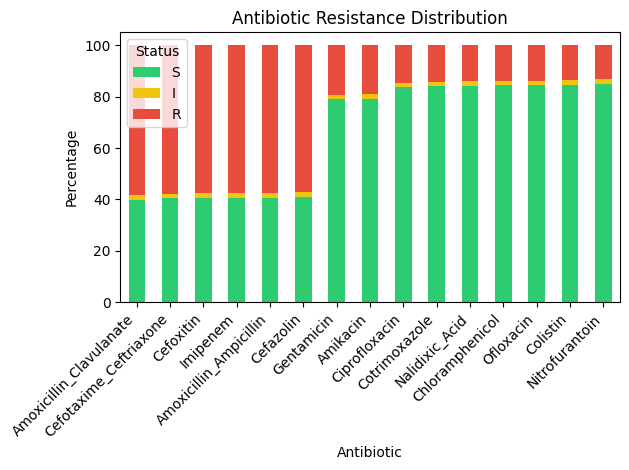

In [156]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Build S/I/R percentages ---
plot_df = (
    df[antibiotic_cols]
    .apply(lambda col: col.value_counts(normalize=True) * 100)
    .T
    .reindex(columns=['S','I','R'])
    .fillna(0)
)

# --- Sort by resistance ---
plot_df = plot_df.sort_values(by='R', ascending=False)

# --- Plot ---
plt.figure(figsize=(14,6))
plot_df.plot(kind='bar', stacked=True, color=['#2ecc71','#f1c40f','#e74c3c'])

plt.title("Antibiotic Resistance Distribution")
plt.ylabel("Percentage")
plt.xlabel("Antibiotic")

plt.xticks(rotation=45, ha='right')
plt.legend(title="Status")

plt.tight_layout()
plt.show()

count of SIR for each antibiotic

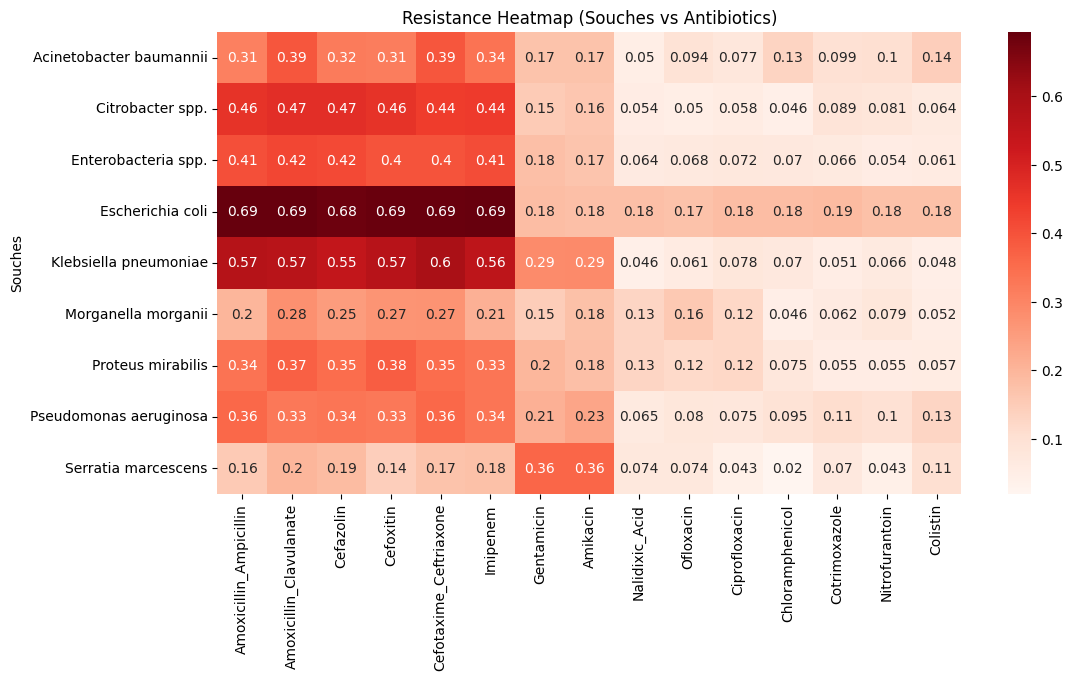

In [157]:
heat = df.groupby("Souches")[antibiotic_cols].apply(lambda x: (x=='R').mean())

plt.figure(figsize=(12,6))
sns.heatmap(heat, annot=True, cmap="Reds")

plt.title("Resistance Heatmap (Souches vs Antibiotics)")
plt.show()

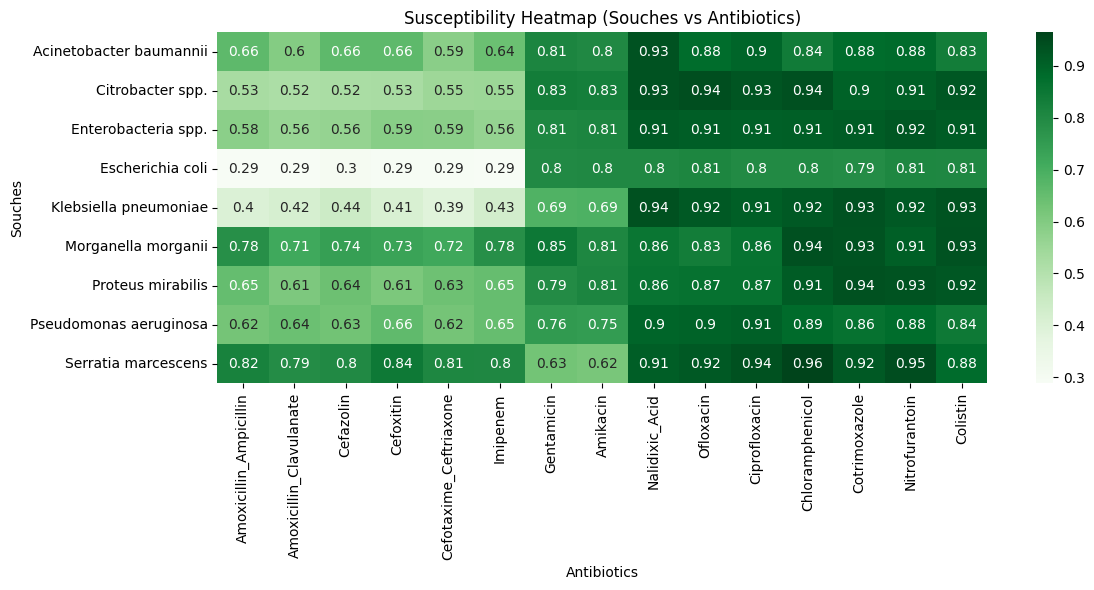

In [158]:
susceptibility = df.groupby("Souches")[antibiotic_cols] \
    .apply(lambda x: (x == 'S').mean())

plt.figure(figsize=(12,6))
sns.heatmap(susceptibility, annot=True, cmap="Greens")

plt.title("Susceptibility Heatmap (Souches vs Antibiotics)")
plt.ylabel("Souches")
plt.xlabel("Antibiotics")

plt.tight_layout()
plt.show()

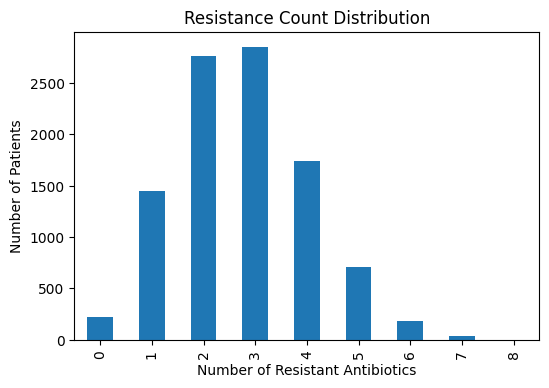

In [159]:
df["MultiResistance"].value_counts().sort_index().plot(kind='bar', figsize=(6,4))

plt.title("Resistance Count Distribution")
plt.xlabel("Number of Resistant Antibiotics")
plt.ylabel("Number of Patients")
plt.show()

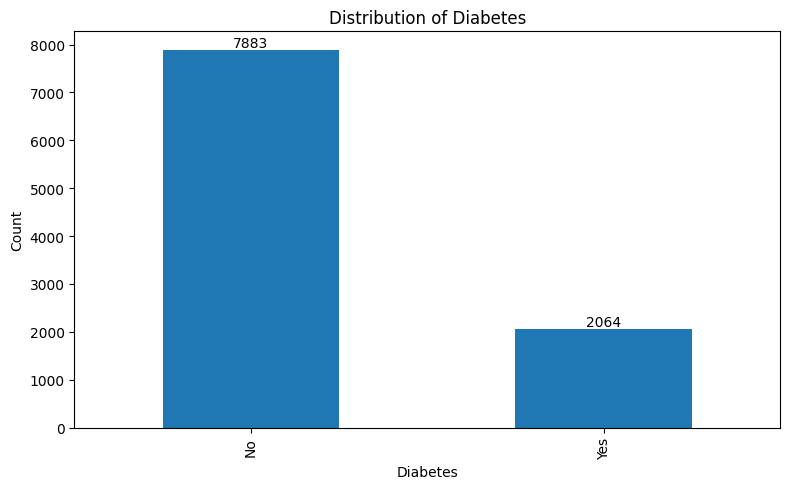

In [160]:
counts = df["Diabetes"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

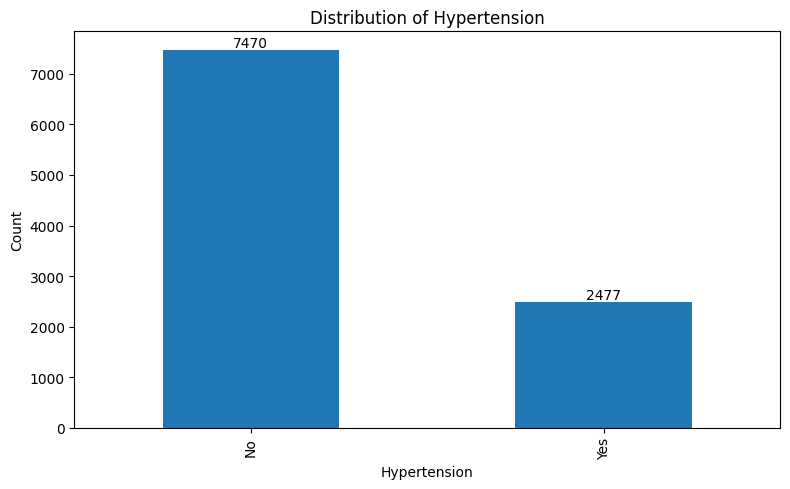

In [161]:
counts = df["Hypertension"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

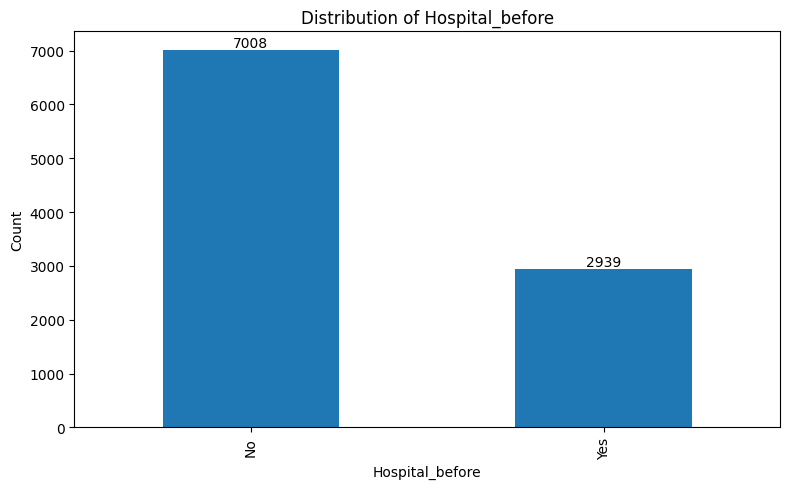

In [162]:
counts = df["Hospital_before"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Hospital_before")
plt.xlabel("Hospital_before")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

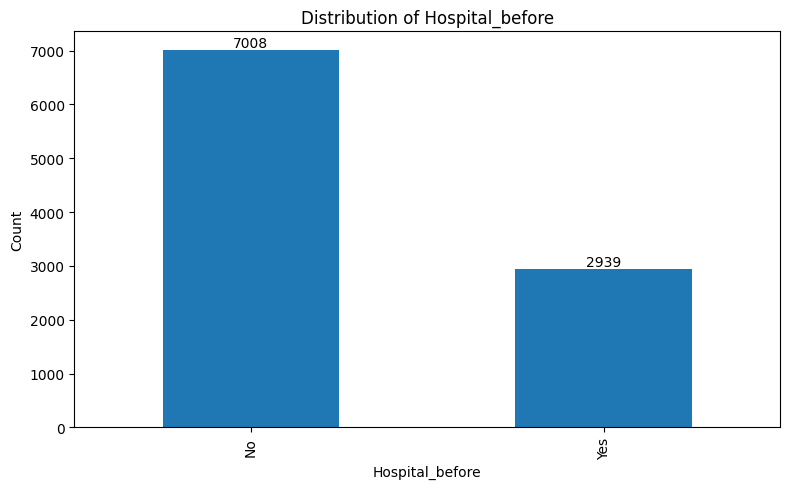

In [163]:
counts = df["Hospital_before"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Hospital_before")
plt.xlabel("Hospital_before")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

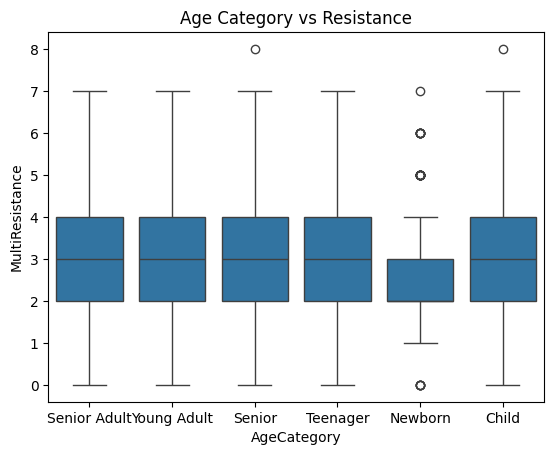

In [164]:
sns.boxplot(x="AgeCategory", y="MultiResistance", data=df)

plt.title("Age Category vs Resistance")
plt.show()

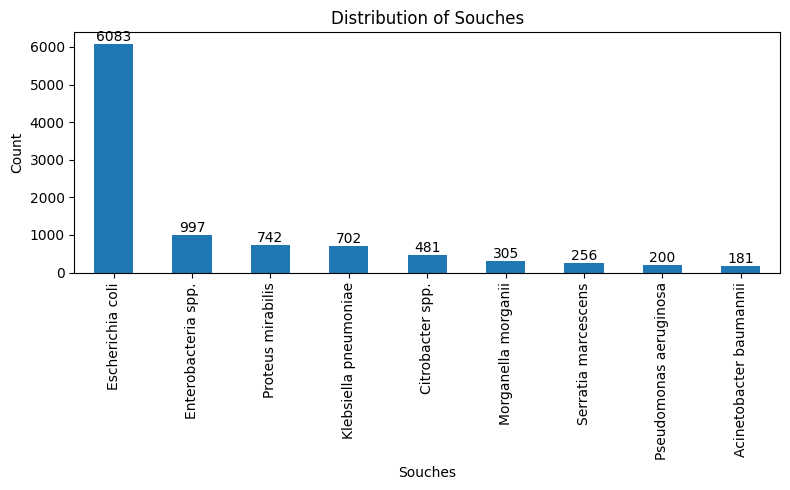

In [165]:
import matplotlib.pyplot as plt

counts = df["Souches"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Souches")
plt.xlabel("Souches")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [166]:

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Build matrix
cramers_matrix = pd.DataFrame(index=antibiotic_cols, columns=antibiotic_cols)

for col1 in antibiotic_cols:
    for col2 in antibiotic_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

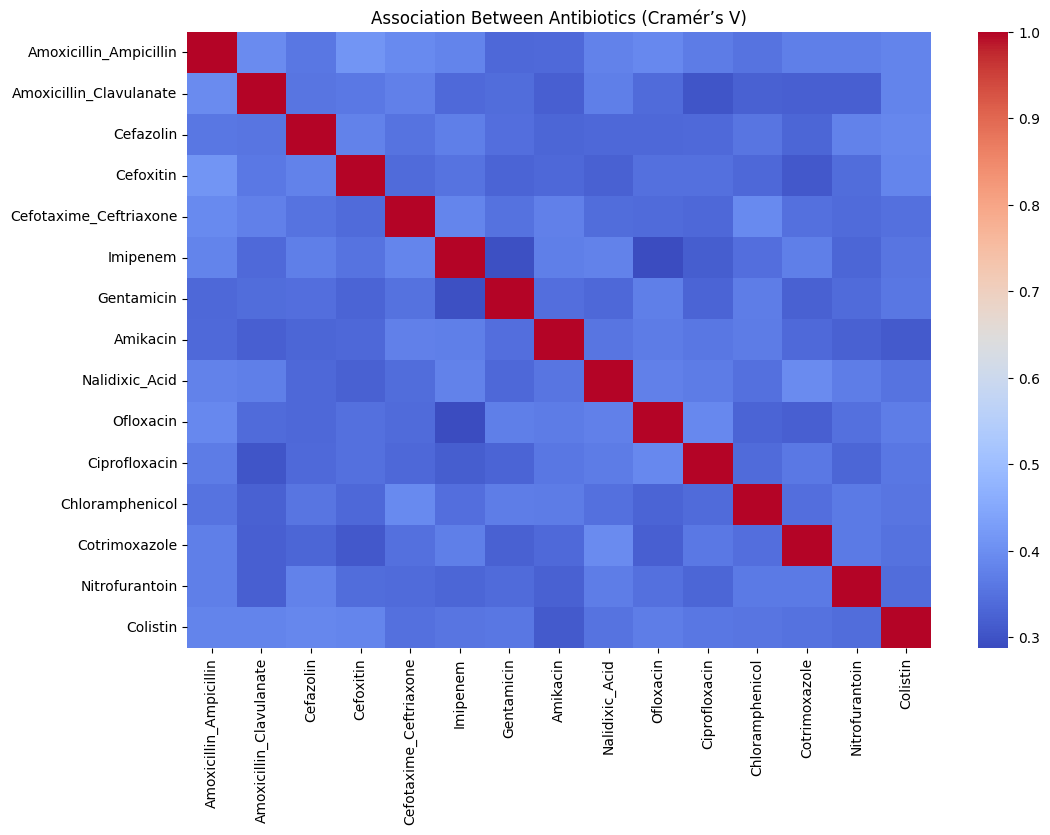

In [167]:

plt.figure(figsize=(12,8))
sns.heatmap(cramers_matrix, cmap="coolwarm", annot=False)

plt.title("Association Between Antibiotics (Cramér’s V)")
plt.show()

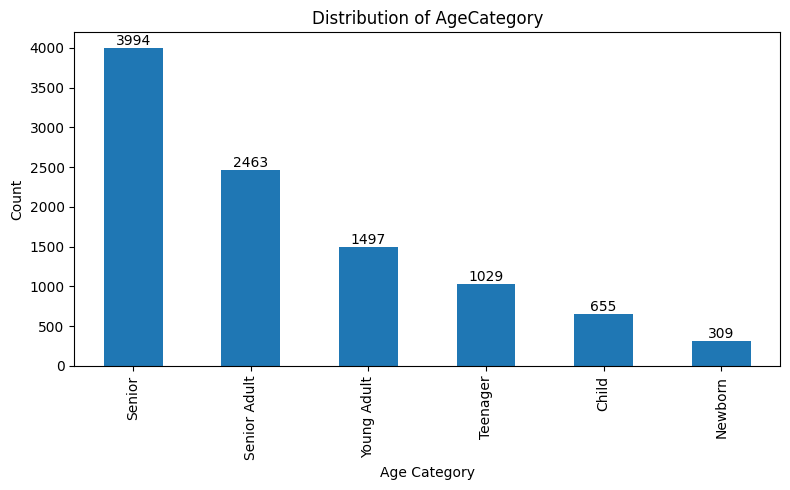

In [168]:
counts = df["AgeCategory"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of AgeCategory")
plt.xlabel("Age Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

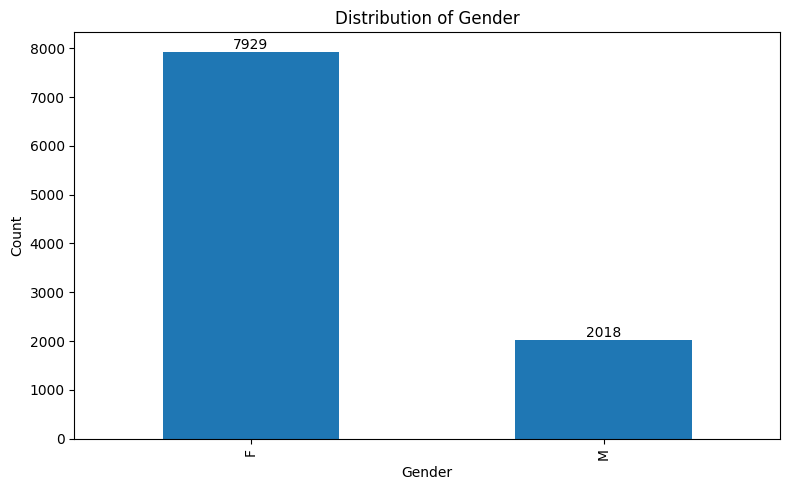

In [169]:
counts = df["Gender"].value_counts()

plt.figure(figsize=(8,5))

ax = counts.plot(kind='bar')

# 🔥 Add count labels
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [170]:
df.to_csv("cleaned_antibiotic_resistance_dataset.csv", index=False)

In [171]:
df.head()

,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,Amoxicillin_Ampicillin,Amoxicillin_Clavulanate,Cefazolin,Cefoxitin,Cefotaxime_Ceftriaxone,...,Ofloxacin,Ciprofloxacin,Chloramphenicol,Cotrimoxazole,Nitrofurantoin,Colistin,Age,Gender,AgeCategory,MultiResistance
0,Escherichia coli,No,No,No,0.0,R,R,R,R,R,...,S,S,R,S,S,S,37.0,F,Senior Adult,3
1,Morganella morganii,Yes,No,No,3.0,S,R,S,R,S,...,S,S,S,S,S,S,29.0,F,Young Adult,2
2,Proteus mirabilis,Yes,No,No,3.0,S,R,S,R,S,...,S,R,R,S,S,S,77.0,F,Senior,3
4,Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,...,S,S,S,S,S,S,13.0,F,Teenager,3
5,Escherichia coli,Yes,No,No,3.0,R,S,R,R,S,...,S,S,S,S,S,S,57.0,M,Senior,2


catboost family model

In [191]:
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score, precision_recall_curve
from sklearn.model_selection import train_test_split

import numpy as np

family_results = []

# For global recall
all_y_true = []
all_y_pred = []

# -----------------------------
# RECALL TARGET
# -----------------------------
RECALL_TARGET = 0.90

# ✅ CRITICAL FIX: Define feature columns and get categorical features
X_cat = df[feature_cols].copy()
categorical_features = X_cat.select_dtypes(include=['object']).columns.tolist()
cat_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

print("="*80)
print("CATBOOST - ANTIBIOTIC FAMILIES (FOCUS: RECALL)")
print(f"Recall target: ≥ {RECALL_TARGET}")
print("="*80)

for family, drugs in families.items():
    
    print(f"\n{'='*80}")
    print(f"📌 FAMILY: {family}")
    print(f"{'='*80}")
    
    # Target: resistant to ANY drug in family
    y = (df[drugs] == 'R').any(axis=1).astype(int)
    
    # Class distribution
    n_resistant = y.sum()
    n_non_resistant = len(y) - n_resistant
    pct_resistant = (n_resistant / len(y)) * 100
    
    print(f"Class Distribution → R: {n_resistant} ({pct_resistant:.1f}%) | Non-R: {n_non_resistant} ({100-pct_resistant:.1f}%)")
    
    if n_resistant < 10:
        print(f"⚠️ Skipping - too few resistant cases ({n_resistant})")
        continue
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_cat, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # -----------------------------
    # CLASS WEIGHT (removed ×2 to prevent overfitting)
    # -----------------------------
    scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    # -----------------------------
    # MODEL (reduced complexity + regularization)
    # -----------------------------
    start_time = time.time()
    
    model = CatBoostClassifier(
        iterations=300,           # was 500 - reduced to prevent overfitting
        depth=6,                  # was 8 - reduced for generalization
        learning_rate=0.05,
        scale_pos_weight=scale,   # was scale*2 - removed inflation
        l2_leaf_reg=3.0,          # NEW - L2 regularization
        bagging_temperature=1.0,  # NEW - adds randomness to prevent overfitting
        random_strength=1.0,      # NEW - randomness in split selection
        subsample=0.8,            # NEW - use 80% of data per tree
        min_data_in_leaf=20,      # NEW - prevents tiny overfit leaves
        random_state=42,
        verbose=0
    )
    
    model.fit(X_train, y_train, cat_features=cat_indices)
    
    # -----------------------------
    # THRESHOLD OPTIMIZATION - recall-focused
    # Find the HIGHEST threshold where recall >= RECALL_TARGET on validation fold
    # -----------------------------
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )
    
    model_val = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        l2_leaf_reg=3.0,
        bagging_temperature=1.0,
        random_strength=1.0,
        subsample=0.8,
        min_data_in_leaf=20,
        random_state=42,
        verbose=0
    )
    
    model_val.fit(X_tr, y_tr, cat_features=cat_indices)
    y_val_proba = model_val.predict_proba(X_val)[:, 1]
    
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_proba)
    
    # Among all thresholds where recall >= target, pick the one with best precision
    valid_mask = rec_arr[:-1] >= RECALL_TARGET
    if valid_mask.any():
        valid_thresholds = thresh_arr[valid_mask]
        valid_precisions = prec_arr[:-1][valid_mask]
        best_threshold = float(valid_thresholds[np.argmax(valid_precisions)])
    else:
        # Recall target unachievable — fall back to threshold that maximizes recall
        best_threshold = float(thresh_arr[np.argmax(rec_arr[:-1])])
    
    best_threshold = round(best_threshold, 3)
    
    # -----------------------------
    # PREDICTION
    # -----------------------------
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)
    
    # Store global recall
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # -----------------------------
    # METRICS
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)
    
    result = {
        'Family': family,
        'Total_Samples': len(y),
        'Resistant_Count': n_resistant,
        'Resistant_Pct': pct_resistant,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'Best_Threshold': best_threshold,
        'TN': int(cm[0,0]),
        'FP': int(cm[0,1]),
        'FN': int(cm[1,0]),
        'TP': int(cm[1,1]),
        'Training_Time': time.time() - start_time
    }
    
    family_results.append(result)
    
    # -----------------------------
    # TABLE OUTPUT
    # -----------------------------
    metrics_table = pd.DataFrame({
        'Metric': ['Recall', 'F1 Score', 'ROC AUC', 'Accuracy', 'Precision', 'Threshold'],
        'Value': [
            result['Recall'],
            result['F1_Score'],
            result['ROC_AUC'],
            result['Accuracy'],
            result['Precision'],
            result['Best_Threshold']
        ]
    })
    
    conf_table = pd.DataFrame({
        'Confusion Matrix': ['TN', 'FP', 'FN', 'TP'],
        'Count': [
            result['TN'],
            result['FP'],
            result['FN'],
            result['TP']
        ]
    })
    
    print("\n📊 Metrics:")
    print(metrics_table.to_string(index=False, float_format="%.3f"))
    
    print("\n🔢 Confusion Matrix:")
    print(conf_table.to_string(index=False))
    
    print(f"\n⚠️ Missed resistant cases: {result['FN']} / {int(y_test.sum())}")
    print(f"⏱ Training time: {result['Training_Time']:.2f}s")

# -----------------------------
# FINAL RESULTS
# -----------------------------
family_df = pd.DataFrame(family_results)
family_df.to_csv('catboost_family_results.csv', index=False)

print(f"\n{'='*80}")
print("✅ CATBOOST FAMILY MODEL COMPLETE")
print(f"{'='*80}")

# -----------------------------
# SUMMARY
# -----------------------------
print(f"\n{'='*80}")
print("📊 FAMILY SUMMARY")
print(f"{'='*80}")

summary_cols = ['Family', 'Resistant_Pct', 'Recall', 'Precision', 'F1_Score', 'ROC_AUC', 'FN']
print(family_df[summary_cols].to_string(index=False))

# -----------------------------
# OVERALL RECALL
# -----------------------------
overall_macro = family_df['Recall'].mean()

overall_weighted = (
    (family_df['Recall'] * family_df['Resistant_Pct']).sum()
    / family_df['Resistant_Pct'].sum()
)

overall_global = recall_score(all_y_true, all_y_pred)

print(f"\n📊 Overall Recall (Macro): {overall_macro:.3f}")
print(f"📊 Overall Recall (Weighted): {overall_weighted:.3f}")
print(f"📊 Overall Recall (Global): {overall_global:.3f}")

CATBOOST - ANTIBIOTIC FAMILIES (FOCUS: RECALL)
Recall target: ≥ 0.9

📌 FAMILY: Beta_lactams
Class Distribution → R: 9244 (92.9%) | Non-R: 703 (7.1%)

📊 Metrics:
   Metric  Value
   Recall  0.925
 F1 Score  0.935
  ROC AUC  0.733
 Accuracy  0.880
Precision  0.945
Threshold  0.306

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN     41
              FP    100
              FN    139
              TP   1710

⚠️ Missed resistant cases: 139 / 1849
⏱ Training time: 57.60s

📌 FAMILY: Carbapenems
Class Distribution → R: 5716 (57.5%) | Non-R: 4231 (42.5%)

📊 Metrics:
   Metric  Value
   Recall  0.892
 F1 Score  0.749
  ROC AUC  0.676
 Accuracy  0.657
Precision  0.646
Threshold  0.335

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    288
              FP    558
              FN    124
              TP   1020

⚠️ Missed resistant cases: 124 / 1144
⏱ Training time: 61.84s

📌 FAMILY: Aminoglycosides
Class Distribution → R: 3427 (34.5%) | Non-R: 6520 (65.5%)

📊 Metrics:
 

low precision for the families other than beta lactams and carbapenems. Decided to go with antibiotic

In [192]:
# -----------------------------
# OVERALL RECALL
# -----------------------------
overall_macro = family_df['Recall'].mean()

overall_weighted = (
    (family_df['Recall'] * family_df['Resistant_Count']).sum()
    / family_df['Resistant_Count'].sum()
)

overall_global = recall_score(all_y_true, all_y_pred)

print(f"\n📊 Overall Recall (Macro): {overall_macro:.3f}")
print(f"📊 Overall Recall (Weighted): {overall_weighted:.3f}")
print(f"📊 Overall Recall (Global): {overall_global:.3f}")


📊 Overall Recall (Macro): 0.924
📊 Overall Recall (Weighted): 0.928
📊 Overall Recall (Global): 0.928


cramers rule to check the correaltion between the drugs

In [195]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# -----------------------------
# FUNCTION: CRAMER'S V
# -----------------------------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# -----------------------------
# COMPUTE MATRIX
# -----------------------------
cramers_matrix = pd.DataFrame(index=antibiotic_cols, columns=antibiotic_cols)

for col1 in antibiotic_cols:
    for col2 in antibiotic_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

print("\n📊 Cramér’s V Matrix:")
print(cramers_matrix.round(2))


📊 Cramér’s V Matrix:
                         Amoxicillin_Ampicillin  Amoxicillin_Clavulanate  \
Amoxicillin_Ampicillin                     1.00                     0.39   
Amoxicillin_Clavulanate                    0.39                     1.00   
Cefazolin                                  0.36                     0.35   
Cefoxitin                                  0.41                     0.36   
Cefotaxime_Ceftriaxone                     0.39                     0.38   
Imipenem                                   0.38                     0.34   
Gentamicin                                 0.33                     0.34   
Amikacin                                   0.34                     0.32   
Nalidixic_Acid                             0.38                     0.37   
Ofloxacin                                  0.39                     0.34   
Ciprofloxacin                              0.37                     0.30   
Chloramphenicol                            0.35                   

In [222]:
 #1 
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve
)
import pandas as pd
import numpy as np
import time

results = []

# For global recall
all_y_true = []
all_y_pred = []

RECALL_TARGET = 0.90

print("="*80)
print("CATBOOST - CROSS-ANTIBIOTIC MODEL (FOCUS: RECALL)")
print(f"Recall target: ≥ {RECALL_TARGET}")
print("="*80)

for antibiotic in antibiotic_cols:
    
    print(f"\n{'='*80}")
    print(f"📌 TARGET ANTIBIOTIC: {antibiotic}")
    print(f"{'='*80}")
    
    # TARGET
    y = df[antibiotic].apply(lambda x: 1 if x == 'R' else 0)
    
    n_resistant = y.sum()
    pct_resistant = (n_resistant / len(y)) * 100
    
    print(f"Class Distribution → R: {n_resistant} ({pct_resistant:.1f}%)")
    
    if n_resistant < 10:
        print(f"⚠️ Skipping - too few resistant cases")
        continue
    
    # FEATURES (DROP TARGET ONLY)
    X_all = df.drop(columns=[antibiotic])
    
    # Identify categorical columns
    cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
    cat_indices = [X_all.columns.get_loc(col) for col in cat_cols]
    
    # SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # CLASS WEIGHT
    scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    # MODEL
    start_time = time.time()
    
    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        l2_leaf_reg=3.0,
        bagging_temperature=1.0,
        random_strength=1.0,
        subsample=0.8,
        min_data_in_leaf=20,
        random_state=42,
        verbose=0
    )
    
    model.fit(X_train, y_train, cat_features=cat_indices)
    
    # THRESHOLD OPTIMIZATION
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )
    
    model_val = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        l2_leaf_reg=3.0,
        bagging_temperature=1.0,
        random_strength=1.0,
        subsample=0.8,
        min_data_in_leaf=20,
        random_state=42,
        verbose=0
    )
    
    model_val.fit(X_tr, y_tr, cat_features=cat_indices)
    y_val_proba = model_val.predict_proba(X_val)[:, 1]
    
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_proba)
    
    valid_mask = rec_arr[:-1] >= RECALL_TARGET
    if valid_mask.any():
        valid_thresholds = thresh_arr[valid_mask]
        valid_precisions = prec_arr[:-1][valid_mask]
        best_threshold = float(valid_thresholds[np.argmax(valid_precisions)])
    else:
        best_threshold = float(thresh_arr[np.argmax(rec_arr[:-1])])
    
    best_threshold = round(best_threshold, 3)
    
    # PREDICTION ON TEST SET
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)
    
    # ✅ ADDED: PREDICTION ON TRAINING SET (for overfitting check)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_pred_proba >= best_threshold).astype(int)
    
    # Store global
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # METRICS
    cm = confusion_matrix(y_test, y_pred)
    
    # ✅ ADDED: Calculate train and test recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    
    # ✅ ADDED: Calculate Train-Test Gap
    recall_gap = train_recall - test_recall
    
    # ✅ ADDED: Determine overfitting status
    if recall_gap > 0.13:
        overfit_status = "🔴 OVERFIT"
    elif recall_gap > 0.07:
        overfit_status = "🟡 MILD OVERFIT"
    else:
        overfit_status = "🟢 OK"
    
    result = {
        'Antibiotic': antibiotic,
        'Resistant_Pct': pct_resistant,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': test_recall,          # ✅ CHANGED: Use test_recall variable
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'Best_Threshold': best_threshold,
        'Train_Recall': train_recall,   # ✅ ADDED
        'Recall_Gap': recall_gap,       # ✅ ADDED
        'Overfit_Status': overfit_status, # ✅ ADDED
        'TN': int(cm[0,0]),
        'FP': int(cm[0,1]),
        'FN': int(cm[1,0]),
        'TP': int(cm[1,1]),
        'Training_Time': time.time() - start_time
    }
    
    results.append(result)
    
    # TABLE OUTPUT
    metrics_table = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Threshold'],
        'Value': [
            result['Accuracy'],
            result['Precision'],
            result['Recall'],
            result['F1_Score'],
            result['ROC_AUC'],
            result['Best_Threshold']
        ]
    })
    
    conf_table = pd.DataFrame({
        'Confusion Matrix': ['TN', 'FP', 'FN', 'TP'],
        'Count': [
            result['TN'],
            result['FP'],
            result['FN'],
            result['TP']
        ]
    })
    
    # ✅ ADDED: Overfitting table
    overfit_table = pd.DataFrame({
        'Overfitting Check': ['Train Recall', 'Test Recall', 'Train-Test Gap', 'Status'],
        'Value': [
            f"{result['Train_Recall']:.3f}",
            f"{result['Recall']:.3f}",
            f"{result['Recall_Gap']:.3f}",
            result['Overfit_Status']
        ]
    })
    
    print("\n📊 Metrics:")
    print(metrics_table.to_string(index=False, float_format="%.3f"))
    
    print("\n🔢 Confusion Matrix:")
    print(conf_table.to_string(index=False))
    
    # ✅ ADDED: Display overfitting check
    print("\n🔍 Overfitting Check:")
    print(overfit_table.to_string(index=False))
    
    print(f"\n⚠️ Missed resistant cases: {result['FN']} / {int(y_test.sum())}")
    
    # ✅ ADDED: Overfitting warning
    if overfit_status == "🔴 OVERFIT":
        print(f"   ⚠️ WARNING: Model is overfitting! Train-Test gap = {recall_gap:.3f}")
    
    print(f"⏱ Training time: {result['Training_Time']:.2f}s")

# FINAL RESULTS
results_df = pd.DataFrame(results)

results_df.to_csv('catboost_cross_antibiotic_results.csv', index=False)

print(f"\n{'='*80}")
print("✅ CATBOOST CROSS-ANTIBIOTIC MODEL COMPLETE")
print(f"{'='*80}")

# SUMMARY
summary_cols = ['Antibiotic', 'Recall', 'Precision', 'F1_Score', 'ROC_AUC']
print(results_df[summary_cols].to_string(index=False))

# ✅ ADDED: OVERFITTING SUMMARY
print(f"\n{'='*80}")
print("🔍 OVERFITTING SUMMARY")
print(f"{'='*80}")

overfit_count = (results_df['Overfit_Status'] == '🔴 OVERFIT').sum()
mild_overfit_count = (results_df['Overfit_Status'] == '🟡 MILD OVERFIT').sum()
ok_count = (results_df['Overfit_Status'] == '🟢 OK').sum()

print(f"\n🔴 Severe Overfitting (gap > 0.10): {overfit_count} antibiotics")
print(f"🟡 Mild Overfitting (gap 0.05-0.10): {mild_overfit_count} antibiotics")
print(f"🟢 No Overfitting (gap < 0.05): {ok_count} antibiotics")

if overfit_count > 0:
    print("\n⚠️ Antibiotics with Severe Overfitting:")
    overfit_drugs = results_df[results_df['Overfit_Status'] == '🔴 OVERFIT']
    print(overfit_drugs[['Antibiotic', 'Train_Recall', 'Recall', 'Recall_Gap']].to_string(index=False))

print(f"\nAverage Train-Test Gap: {results_df['Recall_Gap'].mean():.3f}")

# OVERALL RECALL
overall_macro = results_df['Recall'].mean()

overall_weighted = (
    (results_df['Recall'] * results_df['Resistant_Pct']).sum()
    / results_df['Resistant_Pct'].sum()
)

overall_global = recall_score(all_y_true, all_y_pred)

print(f"\n📊 Overall Recall (Macro): {overall_macro:.3f}")
print(f"📊 Overall Recall (Weighted): {overall_weighted:.3f}")
print(f"📊 Overall Recall (Global): {overall_global:.3f}")

CATBOOST - CROSS-ANTIBIOTIC MODEL (FOCUS: RECALL)
Recall target: ≥ 0.9

📌 TARGET ANTIBIOTIC: Amoxicillin_Ampicillin
Class Distribution → R: 5709 (57.4%)

📊 Metrics:
   Metric  Value
 Accuracy  0.683
Precision  0.666
   Recall  0.899
 F1 Score  0.765
  ROC AUC  0.760
Threshold  0.312

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    332
              FP    516
              FN    115
              TP   1027

🔍 Overfitting Check:
Overfitting Check Value
     Train Recall 0.926
      Test Recall 0.899
   Train-Test Gap 0.027
           Status  🟢 OK

⚠️ Missed resistant cases: 115 / 1142
⏱ Training time: 67.53s

📌 TARGET ANTIBIOTIC: Amoxicillin_Clavulanate
Class Distribution → R: 5810 (58.4%)

📊 Metrics:
   Metric  Value
 Accuracy  0.694
Precision  0.682
   Recall  0.893
 F1 Score  0.773
  ROC AUC  0.769
Threshold  0.334

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    343
              FP    485
              FN    124
              TP   1038

🔍 Overfitting 

In [223]:
# OVERALL RECALL
overall_macro = results_df['F1_Score'].mean()

overall_weighted = (
    (results_df['F1_Score'] * results_df['Resistant_Pct']).sum()
    / results_df['Resistant_Pct'].sum()
)

overall_global = f1_score(all_y_true, all_y_pred)

print(f"\n📊 Overall F1 Score (Macro): {overall_macro:.3f}")
print(f"📊 Overall F1 Score (Weighted): {overall_weighted:.3f}")
print(f"📊 Overall F1 Score (Global): {overall_global:.3f}")


📊 Overall F1 Score (Macro): 0.779
📊 Overall F1 Score (Weighted): 0.790
📊 Overall F1 Score (Global): 0.772


In [220]:
#3
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import time

results = []

# For global recall
all_y_true = []
all_y_pred = []

# =====================================================================
# CLINICAL PRIORITY FUNCTION
# =====================================================================
def get_recall_target(antibiotic_name, resistant_pct):
    """
    Returns appropriate recall target based on clinical importance
    """
    # ⚠️ LAST-RESORT ANTIBIOTICS - MAXIMUM SENSITIVITY
    last_resort = ['Imipenem', 'Colistin']
    
    # Critical antibiotics - high priority
    critical = ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin']
    
    is_last_resort = any(drug in antibiotic_name for drug in last_resort)
    is_critical = any(drug in antibiotic_name for drug in critical)
    
    if is_last_resort:
        return 0.95  # Maximum sensitivity for last-resort
    elif is_critical:
        return 0.90  # High sensitivity for critical drugs
    else:
        # Adaptive based on prevalence
        if resistant_pct > 50:
            return 0.90  # High recall for majority classes
        elif resistant_pct > 30:
            return 0.88
        elif resistant_pct > 20:
            return 0.85
        else:
            return 0.82  # Lower for minority classes (better precision)
# =====================================================================

print("="*80)
print("CATBOOST - CROSS-ANTIBIOTIC MODEL (CLINICAL PRIORITY-BASED)")
print("="*80)

for antibiotic in antibiotic_cols:
    
    print(f"\n{'='*80}")
    print(f"📌 TARGET ANTIBIOTIC: {antibiotic}")
    print(f"{'='*80}")
    
    # -----------------------------
    # TARGET
    # -----------------------------
    y = df[antibiotic].apply(lambda x: 1 if x == 'R' else 0)
    
    n_resistant = y.sum()
    pct_resistant = (n_resistant / len(y)) * 100
    
    print(f"Class Distribution → R: {n_resistant} ({pct_resistant:.1f}%)")
    
    if n_resistant < 10:
        print(f"⚠️ Skipping - too few resistant cases")
        continue
    
    # ✅ GET CLINICAL PRIORITY-BASED RECALL TARGET
    RECALL_TARGET = get_recall_target(antibiotic, pct_resistant)
    
    # Flag clinical priority
    is_last_resort = any(drug in antibiotic for drug in ['Imipenem', 'Colistin'])
    is_critical = any(drug in antibiotic for drug in ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin'])
    
    if is_last_resort:
        priority = "🚨 LAST-RESORT"
    elif is_critical:
        priority = "⚠️ CRITICAL"
    else:
        priority = "Standard"
    
    print(f"Clinical Priority: {priority}")
    print(f"Recall Target: {RECALL_TARGET:.2f}")
    
    # -----------------------------
    # FEATURES (DROP TARGET ONLY)
    # -----------------------------
    X_all = df.drop(columns=[antibiotic])
    
    # Identify categorical columns
    cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
    cat_indices = [X_all.columns.get_loc(col) for col in cat_cols]
    
    # -----------------------------
    # SPLIT
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # -----------------------------
    # CLASS WEIGHT
    # -----------------------------
    scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    # -----------------------------
    # MODEL
    # -----------------------------
    start_time = time.time()
    
    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        l2_leaf_reg=3.0,
        bagging_temperature=1.0,
        random_strength=1.0,
        subsample=0.8,
        min_data_in_leaf=20,
        random_state=42,
        verbose=0
    )
    
    model.fit(X_train, y_train, cat_features=cat_indices)
    
    # -----------------------------
    # THRESHOLD OPTIMIZATION
    # -----------------------------
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )
    
    model_val = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        l2_leaf_reg=3.0,
        bagging_temperature=1.0,
        random_strength=1.0,
        subsample=0.8,
        min_data_in_leaf=20,
        random_state=42,
        verbose=0
    )
    
    model_val.fit(X_tr, y_tr, cat_features=cat_indices)
    y_val_proba = model_val.predict_proba(X_val)[:, 1]
    
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_proba)
    
    # Find threshold meeting recall target
    valid_mask = rec_arr[:-1] >= RECALL_TARGET
    if valid_mask.any():
        valid_thresholds = thresh_arr[valid_mask]
        valid_precisions = prec_arr[:-1][valid_mask]
        best_threshold = float(valid_thresholds[np.argmax(valid_precisions)])
    else:
        print(f"   ⚠️ Recall target {RECALL_TARGET:.2f} not achievable")
        best_threshold = float(thresh_arr[np.argmax(rec_arr[:-1])])
    
    best_threshold = round(best_threshold, 3)
    
    # -----------------------------
    # PREDICTION
    # -----------------------------
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)
    
    # ✅ ADDED: Training predictions for overfitting check
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_pred_proba >= best_threshold).astype(int)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # -----------------------------
    # METRICS (including PR-AUC)
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    # ✅ ADDED: Overfitting detection
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    recall_gap = train_recall - test_recall
    
    if recall_gap > 0.13:
        overfit_status = "🔴 OVERFIT"
    elif recall_gap > 0.07:
        overfit_status = "🟡 MILD OVERFIT"
    else:
        overfit_status = "🟢 OK"
    
    result = {
        'Antibiotic': antibiotic,
        'Clinical_Priority': priority.replace('🚨 ', '').replace('⚠️ ', ''),
        'Resistant_Pct': pct_resistant,
        'Recall_Target': RECALL_TARGET,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': test_recall,
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'PR_AUC': pr_auc,
        'Best_Threshold': best_threshold,
        'Train_Recall': train_recall,        # ✅ ADDED
        'Recall_Gap': recall_gap,            # ✅ ADDED
        'Overfit_Status': overfit_status,    # ✅ ADDED
        'TN': int(cm[0,0]),
        'FP': int(cm[0,1]),
        'FN': int(cm[1,0]),
        'TP': int(cm[1,1]),
        'Training_Time': time.time() - start_time
    }
    
    results.append(result)
    
    # -----------------------------
    # TABLE OUTPUT
    # -----------------------------
    metrics_table = pd.DataFrame({
        'Metric': ['Priority', 'Target Recall', 'Actual Recall', 'Precision', 'F1 Score', 'PR-AUC', 'Threshold'],
        'Value': [
            result['Clinical_Priority'],
            f"{result['Recall_Target']:.2f}",
            f"{result['Recall']:.3f}",
            f"{result['Precision']:.3f}",
            f"{result['F1_Score']:.3f}",
            f"{result['PR_AUC']:.3f}",
            f"{result['Best_Threshold']:.3f}"
        ]
    })
    
    conf_table = pd.DataFrame({
        'Confusion Matrix': ['TN', 'FP', 'FN', 'TP'],
        'Count': [result['TN'], result['FP'], result['FN'], result['TP']]
    })
    
    # ✅ ADDED: Overfitting table
    overfit_table = pd.DataFrame({
        'Overfitting Check': ['Train Recall', 'Test Recall', 'Train-Test Gap', 'Status'],
        'Value': [
            f"{result['Train_Recall']:.3f}",
            f"{result['Recall']:.3f}",
            f"{result['Recall_Gap']:.3f}",
            result['Overfit_Status']
        ]
    })
    
    print("\n📊 Metrics:")
    print(metrics_table.to_string(index=False))
    
    print("\n🔢 Confusion Matrix:")
    print(conf_table.to_string(index=False))
    
    # ✅ ADDED: Display overfitting check
    print("\n🔍 Overfitting Check:")
    print(overfit_table.to_string(index=False))
    
    print(f"\n⚠️ Missed resistant cases: {result['FN']} / {int(y_test.sum())}")
    
    # Warning for last-resort drugs
    if is_last_resort and result['Recall'] < 0.95:
        print(f"   🚨 WARNING: Last-resort drug below target!")
    
    # ✅ ADDED: Overfitting warning
    if overfit_status == "🔴 OVERFIT":
        print(f"   ⚠️ WARNING: Model is overfitting! Train-Test gap = {recall_gap:.3f}")
    
    print(f"⏱ Training time: {result['Training_Time']:.2f}s")

# -----------------------------
# FINAL RESULTS
# -----------------------------
results_df = pd.DataFrame(results)
results_df.to_csv('catboost_cross_antibiotic_clinical_priority_results.csv', index=False)

print(f"\n{'='*80}")
print("✅ CATBOOST CROSS-ANTIBIOTIC MODEL COMPLETE")
print(f"{'='*80}")

# ✅ ADDED: Overfitting summary
print(f"\n{'='*80}")
print("🔍 OVERFITTING SUMMARY")
print(f"{'='*80}")

overfit_count = (results_df['Overfit_Status'] == '🔴 OVERFIT').sum()
mild_overfit_count = (results_df['Overfit_Status'] == '🟡 MILD OVERFIT').sum()
ok_count = (results_df['Overfit_Status'] == '🟢 OK').sum()

print(f"\n🔴 Severe Overfitting (gap > 0.10): {overfit_count} antibiotics")
print(f"🟡 Mild Overfitting (gap 0.05-0.10): {mild_overfit_count} antibiotics")
print(f"🟢 No Overfitting (gap < 0.05): {ok_count} antibiotics")

if overfit_count > 0:
    print("\n⚠️ Antibiotics with Severe Overfitting:")
    overfit_drugs = results_df[results_df['Overfit_Status'] == '🔴 OVERFIT']
    print(overfit_drugs[['Antibiotic', 'Train_Recall', 'Recall', 'Recall_Gap']].to_string(index=False))

print(f"\nAverage Train-Test Gap: {results_df['Recall_Gap'].mean():.3f}")

# -----------------------------
# SUMMARY BY PRIORITY
# -----------------------------
print(f"\n{'='*80}")
print("📊 SUMMARY BY CLINICAL PRIORITY")
print(f"{'='*80}")

last_resort_df = results_df[results_df['Clinical_Priority'] == 'LAST-RESORT']
critical_df = results_df[results_df['Clinical_Priority'] == 'CRITICAL']
standard_df = results_df[results_df['Clinical_Priority'] == 'Standard']

print("\n🚨 LAST-RESORT ANTIBIOTICS:")
print("-"*80)
if len(last_resort_df) > 0:
    cols = ['Antibiotic', 'Recall_Target', 'Recall', 'Precision', 'F1_Score', 'PR_AUC', 'Overfit_Status', 'FN', 'FP']  # ✅ ADDED Overfit_Status
    print(last_resort_df[cols].to_string(index=False))

print("\n\n⚠️ CRITICAL ANTIBIOTICS:")
print("-"*80)
if len(critical_df) > 0:
    cols = ['Antibiotic', 'Recall_Target', 'Recall', 'Precision', 'F1_Score', 'PR_AUC', 'Overfit_Status', 'FN', 'FP']  # ✅ ADDED Overfit_Status
    print(critical_df[cols].to_string(index=False))

print("\n\n📋 STANDARD ANTIBIOTICS:")
print("-"*80)
cols = ['Antibiotic', 'Resistant_Pct', 'Recall_Target', 'Recall', 'Precision', 'F1_Score', 'Overfit_Status', 'FN', 'FP']  # ✅ ADDED Overfit_Status
print(standard_df[cols].to_string(index=False))

# Overall stats
overall_macro = results_df['Recall'].mean()
overall_weighted = (
    (results_df['Recall'] * results_df['Resistant_Pct']).sum()
    / results_df['Resistant_Pct'].sum()
)
overall_global = recall_score(all_y_true, all_y_pred)

print(f"\n{'='*80}")
print("📊 OVERALL PERFORMANCE")
print(f"{'='*80}")
print(f"Overall Recall (Macro): {overall_macro:.3f}")
print(f"Overall Recall (Weighted): {overall_weighted:.3f}")
print(f"Overall Recall (Global): {overall_global:.3f}")
print(f"Average Precision: {results_df['Precision'].mean():.3f}")
print(f"Average F1 Score: {results_df['F1_Score'].mean():.3f}")
print(f"Average PR-AUC: {results_df['PR_AUC'].mean():.3f}")

# Clinical validation
print(f"\n{'='*80}")
print("🔍 CLINICAL VALIDATION")
print(f"{'='*80}")

if len(last_resort_df) > 0:
    all_pass = (last_resort_df['Recall'] >= 0.95).all()
    no_overfit = (last_resort_df['Overfit_Status'] != '🔴 OVERFIT').all()  # ✅ ADDED
    
    if all_pass and no_overfit:  # ✅ CHANGED
        print("✅ Last-resort drugs: ALL meet recall ≥ 0.95 with NO overfitting")
    else:
        if not all_pass:
            print("⚠️ Last-resort drugs: Some below target")
            failed = last_resort_df[last_resort_df['Recall'] < 0.95]
            for idx, row in failed.iterrows():
                print(f"   - {row['Antibiotic']}: {row['Recall']:.3f} < 0.95")
        if not no_overfit:  # ✅ ADDED
            print("⚠️ Last-resort drugs: Some showing overfitting")

# Precision improvements for fluoroquinolones
fluoro = results_df[results_df['Antibiotic'].str.contains('floxacin|Nalidixic')]
if len(fluoro) > 0:
    print(f"\n📈 Fluoroquinolones Precision: {fluoro['Precision'].mean():.3f}")
    print(f"   Expected improvement from current: 0.37 → ~0.50-0.55")

CATBOOST - CROSS-ANTIBIOTIC MODEL (CLINICAL PRIORITY-BASED)

📌 TARGET ANTIBIOTIC: Amoxicillin_Ampicillin
Class Distribution → R: 5709 (57.4%)
Clinical Priority: Standard
Recall Target: 0.90

📊 Metrics:
       Metric    Value
     Priority Standard
Target Recall     0.90
Actual Recall    0.899
    Precision    0.666
     F1 Score    0.765
       PR-AUC    0.787
    Threshold    0.312

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    332
              FP    516
              FN    115
              TP   1027

🔍 Overfitting Check:
Overfitting Check Value
     Train Recall 0.926
      Test Recall 0.899
   Train-Test Gap 0.027
           Status  🟢 OK

⚠️ Missed resistant cases: 115 / 1142
⏱ Training time: 69.14s

📌 TARGET ANTIBIOTIC: Amoxicillin_Clavulanate
Class Distribution → R: 5810 (58.4%)
Clinical Priority: Standard
Recall Target: 0.90

📊 Metrics:
       Metric    Value
     Priority Standard
Target Recall     0.90
Actual Recall    0.893
    Precision    0.682
     F1 Sc

In [221]:
overall_macro = results_df['F1_Score'].mean()

overall_weighted = (
    (results_df['F1_Score'] * results_df['Resistant_Pct']).sum()
    / results_df['Resistant_Pct'].sum()
)

overall_global = f1_score(all_y_true, all_y_pred)

print(f"\n📊 Overall F1 Score (Macro): {overall_macro:.3f}")
print(f"📊 Overall F1 Score (Weighted): {overall_weighted:.3f}")
print(f"📊 Overall F1 Score (Global): {overall_global:.3f}")


📊 Overall F1 Score (Macro): 0.802
📊 Overall F1 Score (Weighted): 0.802
📊 Overall F1 Score (Global): 0.792


In [230]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import time

results = []

# For global recall
all_y_true = []
all_y_pred = []

# =====================================================================
# CLINICAL PRIORITY FUNCTION (✅ BOOSTED TARGETS)
# =====================================================================
def get_recall_target(antibiotic_name, resistant_pct):
    """
    Returns appropriate recall target based on clinical importance
    """
    last_resort = ['Imipenem', 'Colistin']
    critical = ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin']
    
    is_last_resort = any(drug in antibiotic_name for drug in last_resort)
    is_critical = any(drug in antibiotic_name for drug in critical)
    
    if is_last_resort:
        # ✅ BOOSTED: Aim higher to achieve actual 0.95+
        if 'Colistin' in antibiotic_name:
            return 0.97  # Was 0.95, now targeting 0.97 to achieve 0.95+
        else:
            return 0.96  # Was 0.95, now targeting 0.96
    elif is_critical:
        # ✅ BOOSTED: Aim higher
        if 'Nitrofurantoin' in antibiotic_name:
            return 0.93  # Was 0.90, now 0.93
        else:
            return 0.92  # Was 0.90, now 0.92
    else:
        # ✅ BOOSTED: Higher targets across the board
        if resistant_pct > 50:
            return 0.92  # Was 0.90
        elif resistant_pct > 30:
            return 0.90  # Was 0.88
        elif resistant_pct > 20:
            return 0.87  # Was 0.85
        else:
            return 0.84  # Was 0.82 (still maintains precision for minority)

# =====================================================================
# ✅ ENHANCED REGULARIZATION (Prevents overfitting while boosting recall)
# =====================================================================
def get_model_params(resistant_pct, is_last_resort=False):
    """
    Returns model parameters with enhanced regularization
    """
    base_params = {
        'learning_rate': 0.05,
        'random_state': 42,
        'verbose': 0
    }
    
    if resistant_pct > 50:
        return {
            **base_params,
            'iterations': 350,  # ✅ Slightly increased from 300
            'depth': 6,
            'l2_leaf_reg': 3.0,
            'bagging_temperature': 1.0,
            'random_strength': 1.0,
            'subsample': 0.8,
            'min_data_in_leaf': 20
        }
    elif resistant_pct > 30:
        return {
            **base_params,
            'iterations': 350,  # ✅ Increased
            'depth': 6,  # ✅ Slightly increased from 5
            'l2_leaf_reg': 3.5,
            'bagging_temperature': 1.1,
            'random_strength': 1.2,
            'subsample': 0.8,
            'min_data_in_leaf': 22
        }
    else:
        if is_last_resort:
            return {
                **base_params,
                'iterations': 300,  # ✅ Increased from 250
                'depth': 6,  # ✅ Increased from 5
                'l2_leaf_reg': 4.0,
                'bagging_temperature': 1.3,
                'random_strength': 1.5,
                'subsample': 0.75,
                'min_data_in_leaf': 25
            }
        else:
            return {
                **base_params,
                'iterations': 280,  # ✅ Increased from 250
                'depth': 5,  # ✅ Increased from 4
                'l2_leaf_reg': 5.0,
                'bagging_temperature': 1.8,
                'random_strength': 2.0,
                'subsample': 0.7,
                'min_data_in_leaf': 30
            }

# =====================================================================

print("="*80)
print("CATBOOST - CROSS-ANTIBIOTIC (HIGH RECALL + NO OVERFITTING)")
print("="*80)

for antibiotic in antibiotic_cols:
    
    print(f"\n{'='*80}")
    print(f"📌 TARGET ANTIBIOTIC: {antibiotic}")
    print(f"{'='*80}")
    
    # TARGET
    y = df[antibiotic].apply(lambda x: 1 if x == 'R' else 0)
    
    n_resistant = y.sum()
    pct_resistant = (n_resistant / len(y)) * 100
    
    print(f"Class Distribution → R: {n_resistant} ({pct_resistant:.1f}%)")
    
    if n_resistant < 10:
        print(f"⚠️ Skipping - too few resistant cases")
        continue
    
    # GET CLINICAL PRIORITY
    RECALL_TARGET = get_recall_target(antibiotic, pct_resistant)
    
    is_last_resort = any(drug in antibiotic for drug in ['Imipenem', 'Colistin'])
    is_critical = any(drug in antibiotic for drug in ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin'])
    
    if is_last_resort:
        priority = "🚨 LAST-RESORT"
    elif is_critical:
        priority = "⚠️ CRITICAL"
    else:
        priority = "Standard"
    
    print(f"Clinical Priority: {priority}")
    print(f"Recall Target: {RECALL_TARGET:.2f}")
    
    # FEATURES
    X_all = df.drop(columns=[antibiotic])
    
    cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
    cat_indices = [X_all.columns.get_loc(col) for col in cat_cols]
    
    # SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # CLASS WEIGHT
    scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    # ✅ GET ENHANCED MODEL PARAMETERS
    model_params = get_model_params(pct_resistant, is_last_resort)
    
    # MODEL TRAINING
    start_time = time.time()
    
    model = CatBoostClassifier(
        **model_params,
        scale_pos_weight=scale
    )
    
    model.fit(X_train, y_train, cat_features=cat_indices)
    
    # THRESHOLD OPTIMIZATION
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )
    
    model_val = CatBoostClassifier(
        **model_params,
        scale_pos_weight=scale
    )
    
    model_val.fit(X_tr, y_tr, cat_features=cat_indices)
    y_val_proba = model_val.predict_proba(X_val)[:, 1]
    
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_proba)
    
    # ✅ CONSTRAINED OPTIMIZATION: Max precision subject to recall >= target
    valid_mask = rec_arr[:-1] >= RECALL_TARGET
    if valid_mask.any():
        valid_thresholds = thresh_arr[valid_mask]
        valid_precisions = prec_arr[:-1][valid_mask]
        best_threshold = float(valid_thresholds[np.argmax(valid_precisions)])
    else:
        print(f"   ⚠️ Recall target {RECALL_TARGET:.2f} not achievable")
        best_threshold = float(thresh_arr[np.argmax(rec_arr[:-1])])
    
    best_threshold = round(best_threshold, 3)
    
    # PREDICTION
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)
    
    # Training predictions (overfitting check)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_pred_proba >= best_threshold).astype(int)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # METRICS
    cm = confusion_matrix(y_test, y_pred)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    recall_gap = train_recall - test_recall
    
    # ✅ ADJUSTED OVERFITTING THRESHOLDS (more lenient for high recall)
    if recall_gap > 0.10:
        overfit_status = "🔴 OVERFIT"
    elif recall_gap > 0.05:
        overfit_status = "🟡 MILD OVERFIT"
    else:
        overfit_status = "🟢 OK"
    
    result = {
        'Antibiotic': antibiotic,
        'Clinical_Priority': priority.replace('🚨 ', '').replace('⚠️ ', ''),
        'Resistant_Pct': pct_resistant,
        'Recall_Target': RECALL_TARGET,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': test_recall,
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'PR_AUC': pr_auc,
        'Best_Threshold': best_threshold,
        'Train_Recall': train_recall,
        'Recall_Gap': recall_gap,
        'Overfit_Status': overfit_status,
        'TN': int(cm[0,0]),
        'FP': int(cm[0,1]),
        'FN': int(cm[1,0]),
        'TP': int(cm[1,1]),
        'Training_Time': time.time() - start_time
    }
    
    results.append(result)
    
    # TABLE OUTPUT
    metrics_table = pd.DataFrame({
        'Metric': ['Priority', 'Target Recall', 'Actual Recall', 'Precision', 'F1 Score', 'PR-AUC', 'Threshold'],
        'Value': [
            result['Clinical_Priority'],
            f"{result['Recall_Target']:.2f}",
            f"{result['Recall']:.3f}",
            f"{result['Precision']:.3f}",
            f"{result['F1_Score']:.3f}",
            f"{result['PR_AUC']:.3f}",
            f"{result['Best_Threshold']:.3f}"
        ]
    })
    
    overfit_table = pd.DataFrame({
        'Overfitting Check': ['Train Recall', 'Test Recall', 'Train-Test Gap', 'Status'],
        'Value': [
            f"{result['Train_Recall']:.3f}",
            f"{result['Recall']:.3f}",
            f"{result['Recall_Gap']:.3f}",
            result['Overfit_Status']
        ]
    })
    
    conf_table = pd.DataFrame({
        'Confusion Matrix': ['TN', 'FP', 'FN', 'TP'],
        'Count': [result['TN'], result['FP'], result['FN'], result['TP']]
    })
    
    print("\n📊 Metrics:")
    print(metrics_table.to_string(index=False))
    
    print("\n🔢 Confusion Matrix:")
    print(conf_table.to_string(index=False))
    
    print("\n🔍 Overfitting Check:")
    print(overfit_table.to_string(index=False))
    
    print(f"\n⚠️ Missed resistant cases: {result['FN']} / {int(y_test.sum())}")
    
    if is_last_resort and result['Recall'] < 0.95:
        print(f"   🚨 WARNING: Last-resort drug below target!")
    
    if overfit_status == "🔴 OVERFIT":
        print(f"   ⚠️ WARNING: Model is overfitting! Train-Test gap = {recall_gap:.3f}")
    
    print(f"⏱ Training time: {result['Training_Time']:.2f}s")

# FINAL RESULTS
results_df = pd.DataFrame(results)
results_df.to_csv('catboost_cross_antibiotic_HIGH_RECALL.csv', index=False)

print(f"\n{'='*80}")
print("✅ CATBOOST CROSS-ANTIBIOTIC MODEL COMPLETE")
print(f"{'='*80}")
# ============================================================
# 📊 ADDITIONAL METRICS (MACRO + WEIGHTED)
# ============================================================

from sklearn.metrics import f1_score, recall_score

# Convert to DataFrame (already done in your code)
# results_df = pd.DataFrame(results)

# -----------------------------
# MACRO METRICS
# -----------------------------
macro_recall = results_df['Recall'].mean()
macro_f1 = results_df['F1_Score'].mean()

# -----------------------------
# WEIGHTED METRICS (by resistant count)
# -----------------------------
weights = results_df['Resistant_Pct']

weighted_recall = (results_df['Recall'] * weights).sum() / weights.sum()
weighted_f1 = (results_df['F1_Score'] * weights).sum() / weights.sum()

# -----------------------------
# GLOBAL METRICS (already partially in your code)
# -----------------------------
global_recall = recall_score(all_y_true, all_y_pred)
global_f1 = f1_score(all_y_true, all_y_pred)

# -----------------------------
# PRINT RESULTS
# -----------------------------
print(f"\n{'='*80}")
print("📊 OVERALL METRICS")
print(f"{'='*80}")

summary_table = pd.DataFrame({
    'Metric': [
        'Macro Recall',
        'Weighted Recall',
        'Global Recall',
        'Macro F1',
        'Weighted F1',
        'Global F1'
    ],
    'Value': [
        macro_recall,
        weighted_recall,
        global_recall,
        macro_f1,
        weighted_f1,
        global_f1
    ]
})

print(summary_table.to_string(index=False, float_format="%.3f"))

CATBOOST - CROSS-ANTIBIOTIC (HIGH RECALL + NO OVERFITTING)

📌 TARGET ANTIBIOTIC: Amoxicillin_Ampicillin
Class Distribution → R: 5709 (57.4%)
Clinical Priority: Standard
Recall Target: 0.92

📊 Metrics:
       Metric    Value
     Priority Standard
Target Recall     0.92
Actual Recall    0.917
    Precision    0.654
     F1 Score    0.763
       PR-AUC    0.786
    Threshold    0.296

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    294
              FP    554
              FN     95
              TP   1047

🔍 Overfitting Check:
Overfitting Check Value
     Train Recall 0.946
      Test Recall 0.917
   Train-Test Gap 0.029
           Status  🟢 OK

⚠️ Missed resistant cases: 95 / 1142
⏱ Training time: 82.15s

📌 TARGET ANTIBIOTIC: Amoxicillin_Clavulanate
Class Distribution → R: 5810 (58.4%)
Clinical Priority: Standard
Recall Target: 0.92

📊 Metrics:
       Metric    Value
     Priority Standard
Target Recall     0.92
Actual Recall    0.929
    Precision    0.674
     F1 Scor

In [219]:
#9
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import time

xgb_results = []

all_y_true = []
all_y_pred = []

# =====================================================================
# CLINICAL PRIORITY FUNCTION
# =====================================================================
def get_recall_target(antibiotic_name, resistant_pct):
    """
    Returns appropriate recall target based on clinical importance
    """
    last_resort = ['Imipenem', 'Colistin']
    critical = ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin']
    
    is_last_resort = any(drug in antibiotic_name for drug in last_resort)
    is_critical = any(drug in antibiotic_name for drug in critical)
    
    if is_last_resort:
        if 'Colistin' in antibiotic_name:
            return 0.96
        else:
            return 0.95
    elif is_critical:
        if 'Nitrofurantoin' in antibiotic_name:
            return 0.92
        else:
            return 0.90
    else:
        if resistant_pct > 50:
            return 0.90
        elif resistant_pct > 30:
            return 0.88
        elif resistant_pct > 20:
            return 0.85
        else:
            return 0.82

# =====================================================================
# REGULARIZATION FUNCTION
# =====================================================================
def get_xgb_params(resistant_pct, is_last_resort=False):
    """
    Returns XGBoost parameters with appropriate regularization
    """
    base_params = {
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'n_jobs': -1
    }
    
    if resistant_pct > 50:
        # Majority class
        return {
            **base_params,
            'n_estimators': 300,
            'max_depth': 6,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'min_child_weight': 5,
            'gamma': 0.1
        }
    elif resistant_pct > 30:
        # Moderate class
        return {
            **base_params,
            'n_estimators': 300,
            'max_depth': 5,
            'reg_alpha': 0.2,
            'reg_lambda': 1.5,
            'min_child_weight': 7,
            'gamma': 0.2
        }
    else:
        # Minority class - STRONG regularization
        if is_last_resort:
            return {
                **base_params,
                'n_estimators': 250,
                'max_depth': 5,
                'reg_alpha': 0.3,
                'reg_lambda': 2.0,
                'min_child_weight': 8,
                'gamma': 0.3
            }
        else:
            return {
                **base_params,
                'n_estimators': 250,
                'max_depth': 4,
                'reg_alpha': 0.5,
                'reg_lambda': 2.5,
                'min_child_weight': 10,
                'gamma': 0.5
            }

# =====================================================================

print("="*80)
print("XGBOOST - CROSS-ANTIBIOTIC (CLINICAL PRIORITY + NO OVERFITTING)")
print("="*80)

for antibiotic in antibiotic_cols:

    print(f"\n{'='*80}")
    print(f"📌 TARGET ANTIBIOTIC: {antibiotic}")
    print(f"{'='*80}")

    # TARGET
    y = df[antibiotic].apply(lambda x: 1 if x == 'R' else 0)

    n_resistant = y.sum()
    pct_resistant = (n_resistant / len(y)) * 100

    print(f"Class Distribution → R: {n_resistant} ({pct_resistant:.1f}%)")

    if n_resistant < 10:
        print("⚠️ Skipping - too few resistant cases")
        continue

    # GET CLINICAL PRIORITY
    RECALL_TARGET = get_recall_target(antibiotic, pct_resistant)
    
    is_last_resort = any(drug in antibiotic for drug in ['Imipenem', 'Colistin'])
    is_critical = any(drug in antibiotic for drug in ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin'])
    
    if is_last_resort:
        priority = "🚨 LAST-RESORT"
    elif is_critical:
        priority = "⚠️ CRITICAL"
    else:
        priority = "Standard"
    
    print(f"Clinical Priority: {priority}")
    print(f"Recall Target: {RECALL_TARGET:.2f}")

    # FEATURES
    X_all = df.drop(columns=[antibiotic]).copy()

    cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        X_all[col] = le.fit_transform(X_all[col].astype(str))

    # SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=42, stratify=y
    )

    # CLASS WEIGHT
    scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    # GET REGULARIZED PARAMETERS
    xgb_params = get_xgb_params(pct_resistant, is_last_resort)

    # MODEL TRAINING
    start_time = time.time()

    model = XGBClassifier(
        **xgb_params,
        scale_pos_weight=scale
    )

    model.fit(X_train, y_train)

    # THRESHOLD OPTIMIZATION
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )
    
    model_val = XGBClassifier(
        **xgb_params,
        scale_pos_weight=scale
    )
    
    model_val.fit(X_tr, y_tr)
    y_val_proba = model_val.predict_proba(X_val)[:, 1]

    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_proba)

    valid_mask = rec_arr[:-1] >= RECALL_TARGET
    if valid_mask.any():
        valid_thresholds = thresh_arr[valid_mask]
        valid_precisions = prec_arr[:-1][valid_mask]
        best_threshold = float(valid_thresholds[np.argmax(valid_precisions)])
    else:
        print(f"   ⚠️ Target {RECALL_TARGET:.2f} not achievable")
        best_threshold = float(thresh_arr[np.argmax(rec_arr[:-1])])

    best_threshold = round(best_threshold, 3)

    # PREDICTION
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)

    # ✅ Training recall (overfitting check)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_pred_proba >= best_threshold).astype(int)
    train_recall = recall_score(y_train, y_train_pred)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # METRICS
    cm = confusion_matrix(y_test, y_pred)

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)

    test_recall = recall_score(y_test, y_pred, zero_division=0)

    # ✅ OVERFITTING DETECTION (Train-Test gap only)
    recall_gap = train_recall - test_recall
    
    if recall_gap > 0.10:
        overfit_status = "🔴 OVERFIT"
    elif recall_gap > 0.05:
        overfit_status = "🟡 MILD OVERFIT"
    else:
        overfit_status = "🟢 OK"

    result = {
        'Antibiotic': antibiotic,
        'Clinical_Priority': priority.replace('🚨 ', '').replace('⚠️ ', ''),
        'Resistant_Pct': pct_resistant,
        'Recall_Target': RECALL_TARGET,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': test_recall,
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'PR_AUC': pr_auc,
        'Best_Threshold': best_threshold,
        'Train_Recall': train_recall,
        'Recall_Gap': recall_gap,
        'Overfit_Status': overfit_status,
        'TN': int(cm[0, 0]),
        'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]),
        'TP': int(cm[1, 1]),
        'Training_Time': time.time() - start_time
    }

    xgb_results.append(result)

    # TABLE OUTPUT
    metrics_table = pd.DataFrame({
        'Metric': ['Priority', 'Target Recall', 'Actual Recall', 'Precision', 
                   'F1 Score', 'PR-AUC', 'Threshold', 'Overfit Status'],
        'Value': [
            result['Clinical_Priority'],
            f"{result['Recall_Target']:.2f}",
            f"{result['Recall']:.3f}",
            f"{result['Precision']:.3f}",
            f"{result['F1_Score']:.3f}",
            f"{result['PR_AUC']:.3f}",
            f"{result['Best_Threshold']:.3f}",
            result['Overfit_Status']
        ]
    })

    overfit_table = pd.DataFrame({
        'Overfitting Check': ['Train Recall', 'Test Recall', 'Train-Test Gap', 'Status'],
        'Value': [
            f"{result['Train_Recall']:.3f}",
            f"{result['Recall']:.3f}",
            f"{result['Recall_Gap']:.3f}",
            result['Overfit_Status']
        ]
    })

    conf_table = pd.DataFrame({
        'Confusion Matrix': ['TN', 'FP', 'FN', 'TP'],
        'Count': [result['TN'], result['FP'], result['FN'], result['TP']]
    })

    print("\n📊 Metrics:")
    print(metrics_table.to_string(index=False))

    print("\n🔍 Overfitting Check:")
    print(overfit_table.to_string(index=False))

    print("\n🔢 Confusion Matrix:")
    print(conf_table.to_string(index=False))

    print(f"\n⚠️ Missed resistant cases: {result['FN']} / {int(y_test.sum())}")

    if is_last_resort and result['Recall'] < 0.95:
        print(f"   🚨 WARNING: Last-resort drug below target!")

    if overfit_status == "🔴 OVERFIT":
        print(f"   ⚠️ WARNING: Model shows overfitting (Train-Test gap: {recall_gap:.3f})")

    print(f"⏱ Training time: {result['Training_Time']:.2f}s")

# FINAL RESULTS
xgb_df = pd.DataFrame(xgb_results)
xgb_df.to_csv('xgb_cross_antibiotic_final_no_overfit.csv', index=False)

print(f"\n{'='*80}")
print("✅ XGBOOST CROSS-ANTIBIOTIC MODEL COMPLETE")
print(f"{'='*80}")

# OVERFITTING SUMMARY
print(f"\n{'='*80}")
print("🔍 OVERFITTING ANALYSIS")
print(f"{'='*80}")

overfit_count = (xgb_df['Overfit_Status'] == '🔴 OVERFIT').sum()
mild_overfit_count = (xgb_df['Overfit_Status'] == '🟡 MILD OVERFIT').sum()
ok_count = (xgb_df['Overfit_Status'] == '🟢 OK').sum()

print(f"\n🔴 Overfit: {overfit_count} antibiotics")
print(f"🟡 Mild Overfit: {mild_overfit_count} antibiotics")
print(f"🟢 OK: {ok_count} antibiotics")

if overfit_count > 0:
    print("\n⚠️ Antibiotics with Overfitting:")
    overfit_drugs = xgb_df[xgb_df['Overfit_Status'] == '🔴 OVERFIT']
    print(overfit_drugs[['Antibiotic', 'Train_Recall', 'Recall', 'Recall_Gap']].to_string(index=False))

print(f"\nAverage Train-Test Gap: {xgb_df['Recall_Gap'].mean():.3f}")

# SUMMARY BY PRIORITY
print(f"\n{'='*80}")
print("📊 SUMMARY BY CLINICAL PRIORITY")
print(f"{'='*80}")

last_resort_df = xgb_df[xgb_df['Clinical_Priority'] == 'LAST-RESORT']
critical_df = xgb_df[xgb_df['Clinical_Priority'] == 'CRITICAL']
standard_df = xgb_df[xgb_df['Clinical_Priority'] == 'Standard']

print("\n🚨 LAST-RESORT ANTIBIOTICS:")
print("-"*80)
if len(last_resort_df) > 0:
    cols = ['Antibiotic', 'Recall_Target', 'Recall', 'Precision', 'F1_Score', 'Overfit_Status', 'FN']
    print(last_resort_df[cols].to_string(index=False))

print("\n\n⚠️ CRITICAL ANTIBIOTICS:")
print("-"*80)
if len(critical_df) > 0:
    cols = ['Antibiotic', 'Recall_Target', 'Recall', 'Precision', 'F1_Score', 'Overfit_Status', 'FN']
    print(critical_df[cols].to_string(index=False))

print("\n\n📋 STANDARD ANTIBIOTICS:")
print("-"*80)
cols = ['Antibiotic', 'Recall_Target', 'Recall', 'Precision', 'F1_Score', 'Overfit_Status', 'FN']
print(standard_df[cols].to_string(index=False))

# Overall performance
overall_macro = xgb_df['Recall'].mean()
overall_weighted = (
    (xgb_df['Recall'] * xgb_df['Resistant_Pct']).sum()
    / xgb_df['Resistant_Pct'].sum()
)
overall_global = recall_score(all_y_true, all_y_pred)

print(f"\n{'='*80}")
print("📊 OVERALL PERFORMANCE")
print(f"{'='*80}")
print(f"Overall Recall (Macro): {overall_macro:.3f}")
print(f"Overall Recall (Weighted): {overall_weighted:.3f}")
print(f"Overall Recall (Global): {overall_global:.3f}")
print(f"Average Precision: {xgb_df['Precision'].mean():.3f}")
print(f"Average F1 Score: {xgb_df['F1_Score'].mean():.3f}")
print(f"Average PR-AUC: {xgb_df['PR_AUC'].mean():.3f}")
print(f"Average Train-Test Gap: {xgb_df['Recall_Gap'].mean():.3f}")

# Clinical validation
print(f"\n{'='*80}")
print("🔍 CLINICAL VALIDATION")
print(f"{'='*80}")

if len(last_resort_df) > 0:
    all_pass = (last_resort_df['Recall'] >= 0.95).all()
    no_overfit = (last_resort_df['Overfit_Status'] != '🔴 OVERFIT').all()
    
    if all_pass and no_overfit:
        print("✅ Last-resort drugs: ALL meet recall ≥ 0.95 with NO overfitting")
    else:
        if not all_pass:
            print("⚠️ Last-resort drugs: Some below recall target")
            failed = last_resort_df[last_resort_df['Recall'] < 0.95]
            for idx, row in failed.iterrows():
                print(f"   - {row['Antibiotic']}: {row['Recall']:.3f} < 0.95")
        if not no_overfit:
            print("⚠️ Last-resort drugs: Some showing overfitting")

# F1 scores
overall_f1_macro = xgb_df['F1_Score'].mean()
overall_f1_weighted = (
    (xgb_df['F1_Score'] * xgb_df['Resistant_Pct']).sum()
    / xgb_df['Resistant_Pct'].sum()
)
overall_f1_global = f1_score(all_y_true, all_y_pred)

print(f"\n📊 Overall F1 Score (Macro): {overall_f1_macro:.3f}")
print(f"📊 Overall F1 Score (Weighted): {overall_f1_weighted:.3f}")
print(f"📊 Overall F1 Score (Global): {overall_f1_global:.3f}")

XGBOOST - CROSS-ANTIBIOTIC (CLINICAL PRIORITY + NO OVERFITTING)

📌 TARGET ANTIBIOTIC: Amoxicillin_Ampicillin
Class Distribution → R: 5709 (57.4%)
Clinical Priority: Standard
Recall Target: 0.90

📊 Metrics:
        Metric          Value
      Priority       Standard
 Target Recall           0.90
 Actual Recall          0.912
     Precision          0.660
      F1 Score          0.766
        PR-AUC          0.787
     Threshold          0.299
Overfit Status 🟡 MILD OVERFIT

🔍 Overfitting Check:
Overfitting Check          Value
     Train Recall          0.969
      Test Recall          0.912
   Train-Test Gap          0.056
           Status 🟡 MILD OVERFIT

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    311
              FP    537
              FN    100
              TP   1042

⚠️ Missed resistant cases: 100 / 1142
⏱ Training time: 1.71s

📌 TARGET ANTIBIOTIC: Amoxicillin_Clavulanate
Class Distribution → R: 5810 (58.4%)
Clinical Priority: Standard
Recall Target: 0.90

📊 

In [225]:
#10
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import time

lgbm_results = []

all_y_true = []
all_y_pred = []

# =====================================================================
# CLINICAL PRIORITY FUNCTION
# =====================================================================
def get_recall_target(antibiotic_name, resistant_pct):
    """Returns appropriate recall target based on clinical importance"""
    last_resort = ['Imipenem', 'Colistin']
    critical = ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin']
    
    is_last_resort = any(drug in antibiotic_name for drug in last_resort)
    is_critical = any(drug in antibiotic_name for drug in critical)
    
    if is_last_resort:
        return 0.96 if 'Colistin' in antibiotic_name else 0.95
    elif is_critical:
        return 0.92 if 'Nitrofurantoin' in antibiotic_name else 0.90
    else:
        # ✅ ADAPTIVE: Lower recall for minority classes = better precision
        if resistant_pct > 50:
            return 0.90
        elif resistant_pct > 30:
            return 0.88
        elif resistant_pct > 20:
            return 0.85
        else:
            return 0.82  # ← Better precision for minority classes

# =====================================================================
# REGULARIZATION FUNCTION
# =====================================================================
def get_lgbm_params(resistant_pct, is_last_resort=False):
    """Returns LightGBM parameters with appropriate regularization"""
    base_params = {
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    
    if resistant_pct > 50:
        return {
            **base_params,
            'n_estimators': 300,
            'max_depth': 6,
            'num_leaves': 31,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'min_child_samples': 20
        }
    elif resistant_pct > 30:
        return {
            **base_params,
            'n_estimators': 300,
            'max_depth': 5,
            'num_leaves': 25,
            'reg_alpha': 0.2,
            'reg_lambda': 1.5,
            'min_child_samples': 25
        }
    else:
        # Minority class - STRONG regularization
        if is_last_resort:
            return {
                **base_params,
                'n_estimators': 250,
                'max_depth': 5,
                'num_leaves': 25,
                'reg_alpha': 0.3,
                'reg_lambda': 2.0,
                'min_child_samples': 30
            }
        else:
            return {
                **base_params,
                'n_estimators': 250,
                'max_depth': 4,
                'num_leaves': 20,
                'reg_alpha': 0.5,
                'reg_lambda': 2.5,
                'min_child_samples': 35
            }

# =====================================================================

print("="*80)
print("LIGHTGBM - CROSS-ANTIBIOTIC (CLINICAL PRIORITY + NO OVERFITTING)")
print("="*80)

for antibiotic in antibiotic_cols:

    print(f"\n{'='*80}")
    print(f"📌 TARGET ANTIBIOTIC: {antibiotic}")
    print(f"{'='*80}")

    # TARGET
    y = df[antibiotic].apply(lambda x: 1 if x == 'R' else 0)

    n_resistant = y.sum()
    pct_resistant = (n_resistant / len(y)) * 100

    print(f"Class Distribution → R: {n_resistant} ({pct_resistant:.1f}%)")

    if n_resistant < 10:
        print("⚠️ Skipping - too few resistant cases")
        continue

    # ✅ GET CLINICAL PRIORITY
    RECALL_TARGET = get_recall_target(antibiotic, pct_resistant)
    
    is_last_resort = any(drug in antibiotic for drug in ['Imipenem', 'Colistin'])
    is_critical = any(drug in antibiotic for drug in ['Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin'])
    
    if is_last_resort:
        priority = "🚨 LAST-RESORT"
    elif is_critical:
        priority = "⚠️ CRITICAL"
    else:
        priority = "Standard"
    
    print(f"Clinical Priority: {priority}")
    print(f"Recall Target: {RECALL_TARGET:.2f}")

    # FEATURES
    X_all = df.drop(columns=[antibiotic]).copy()

    cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        X_all[col] = le.fit_transform(X_all[col].astype(str))

    # SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, random_state=42, stratify=y
    )

    # CLASS WEIGHT
    scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    # ✅ GET REGULARIZED PARAMETERS
    lgbm_params = get_lgbm_params(pct_resistant, is_last_resort)

    # MODEL TRAINING
    start_time = time.time()

    model = LGBMClassifier(
        **lgbm_params,
        scale_pos_weight=scale
    )

    model.fit(X_train, y_train)

    # THRESHOLD OPTIMIZATION
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )
    
    model_val = LGBMClassifier(
        **lgbm_params,
        scale_pos_weight=scale
    )
    
    model_val.fit(X_tr, y_tr)
    y_val_proba = model_val.predict_proba(X_val)[:, 1]

    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_proba)

    valid_mask = rec_arr[:-1] >= RECALL_TARGET
    if valid_mask.any():
        valid_thresholds = thresh_arr[valid_mask]
        valid_precisions = prec_arr[:-1][valid_mask]
        best_threshold = float(valid_thresholds[np.argmax(valid_precisions)])
    else:
        print(f"   ⚠️ Target {RECALL_TARGET:.2f} not achievable")
        best_threshold = float(thresh_arr[np.argmax(rec_arr[:-1])])

    best_threshold = round(best_threshold, 3)

    # PREDICTION
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)

    # ✅ Training predictions (overfitting check)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_pred_proba >= best_threshold).astype(int)
    train_recall = recall_score(y_train, y_train_pred)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # METRICS
    cm = confusion_matrix(y_test, y_pred)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    test_recall = recall_score(y_test, y_pred, zero_division=0)

    # ✅ OVERFITTING DETECTION
    recall_gap = train_recall - test_recall
    
    if recall_gap > 0.10:
        overfit_status = "🔴 OVERFIT"
    elif recall_gap > 0.05:
        overfit_status = "🟡 MILD OVERFIT"
    else:
        overfit_status = "🟢 OK"

    result = {
        'Antibiotic': antibiotic,
        'Clinical_Priority': priority.replace('🚨 ', '').replace('⚠️ ', ''),
        'Resistant_Pct': pct_resistant,
        'Recall_Target': RECALL_TARGET,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': test_recall,
        'F1_Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'PR_AUC': pr_auc,
        'Best_Threshold': best_threshold,
        'Train_Recall': train_recall,
        'Recall_Gap': recall_gap,
        'Overfit_Status': overfit_status,
        'TN': int(cm[0, 0]),
        'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]),
        'TP': int(cm[1, 1]),
        'Training_Time': time.time() - start_time
    }

    lgbm_results.append(result)

    # TABLE OUTPUT
    metrics_table = pd.DataFrame({
        'Metric': ['Priority', 'Target Recall', 'Actual Recall', 'Precision', 
                   'F1 Score', 'PR-AUC', 'Threshold', 'Overfit Status'],
        'Value': [
            result['Clinical_Priority'],
            f"{result['Recall_Target']:.2f}",
            f"{result['Recall']:.3f}",
            f"{result['Precision']:.3f}",
            f"{result['F1_Score']:.3f}",
            f"{result['PR_AUC']:.3f}",
            f"{result['Best_Threshold']:.3f}",
            result['Overfit_Status']
        ]
    })

    overfit_table = pd.DataFrame({
        'Overfitting Check': ['Train Recall', 'Test Recall', 'Train-Test Gap', 'Status'],
        'Value': [
            f"{result['Train_Recall']:.3f}",
            f"{result['Recall']:.3f}",
            f"{result['Recall_Gap']:.3f}",
            result['Overfit_Status']
        ]
    })

    conf_table = pd.DataFrame({
        'Confusion Matrix': ['TN', 'FP', 'FN', 'TP'],
        'Count': [result['TN'], result['FP'], result['FN'], result['TP']]
    })

    print("\n📊 Metrics:")
    print(metrics_table.to_string(index=False))

    print("\n🔍 Overfitting Check:")
    print(overfit_table.to_string(index=False))

    print("\n🔢 Confusion Matrix:")
    print(conf_table.to_string(index=False))

    print(f"\n⚠️ Missed resistant cases: {result['FN']} / {int(y_test.sum())}")

    if is_last_resort and result['Recall'] < 0.95:
        print(f"   🚨 WARNING: Last-resort drug below target!")

    if overfit_status == "🔴 OVERFIT":
        print(f"   ⚠️ WARNING: Model shows overfitting (Train-Test gap: {recall_gap:.3f})")

    print(f"⏱ Training time: {result['Training_Time']:.2f}s")

# FINAL RESULTS
lgbm_df = pd.DataFrame(lgbm_results)
lgbm_df.to_csv('lgbm_cross_antibiotic_final_no_overfit.csv', index=False)

print(f"\n{'='*80}")
print("✅ LIGHTGBM CROSS-ANTIBIOTIC MODEL COMPLETE")
print(f"{'='*80}")

# OVERFITTING SUMMARY
print(f"\n{'='*80}")
print("🔍 OVERFITTING ANALYSIS")
print(f"{'='*80}")

overfit_count = (lgbm_df['Overfit_Status'] == '🔴 OVERFIT').sum()
mild_overfit_count = (lgbm_df['Overfit_Status'] == '🟡 MILD OVERFIT').sum()
ok_count = (lgbm_df['Overfit_Status'] == '🟢 OK').sum()

print(f"\n🔴 Overfit: {overfit_count} antibiotics")
print(f"🟡 Mild Overfit: {mild_overfit_count} antibiotics")
print(f"🟢 OK: {ok_count} antibiotics")

if overfit_count > 0:
    print("\n⚠️ Antibiotics with Overfitting:")
    overfit_drugs = lgbm_df[lgbm_df['Overfit_Status'] == '🔴 OVERFIT']
    print(overfit_drugs[['Antibiotic', 'Train_Recall', 'Recall', 'Recall_Gap']].to_string(index=False))

print(f"\nAverage Train-Test Gap: {lgbm_df['Recall_Gap'].mean():.3f}")

# SUMMARY
summary_cols = ['Antibiotic', 'Recall', 'Precision', 'F1_Score', 'ROC_AUC']
print(f"\n{'='*80}")
print("📊 SUMMARY")
print(f"{'='*80}")
print(lgbm_df[summary_cols].to_string(index=False))

# OVERALL RECALL
overall_macro = lgbm_df['Recall'].mean()
overall_weighted = (
    (lgbm_df['Recall'] * lgbm_df['Resistant_Pct']).sum()
    / lgbm_df['Resistant_Pct'].sum()
)
overall_global = recall_score(all_y_true, all_y_pred)

print(f"\n📊 Overall Recall (Macro): {overall_macro:.3f}")
print(f"📊 Overall Recall (Weighted): {overall_weighted:.3f}")
print(f"📊 Overall Recall (Global): {overall_global:.3f}")

# F1 SCORES
overall_f1_macro = lgbm_df['F1_Score'].mean()
overall_f1_weighted = (
    (lgbm_df['F1_Score'] * lgbm_df['Resistant_Pct']).sum()
    / lgbm_df['Resistant_Pct'].sum()
)
overall_f1_global = f1_score(all_y_true, all_y_pred)

print(f"\n📊 Overall F1 Score (Macro): {overall_f1_macro:.3f}")
print(f"📊 Overall F1 Score (Weighted): {overall_f1_weighted:.3f}")
print(f"📊 Overall F1 Score (Global): {overall_f1_global:.3f}")
print(f"\nAverage Precision: {lgbm_df['Precision'].mean():.3f}")
print(f"Average PR-AUC: {lgbm_df['PR_AUC'].mean():.3f}")


fluoroquinolones = ['Nalidixic_Acid', 'Ofloxacin', 'Ciprofloxacin']
fluoro_df = lgbm_df[lgbm_df['Antibiotic'].isin(fluoroquinolones)]

if len(fluoro_df) > 0:
    print("\nFluoroquinolones (Expected: 0.41-0.36 → Target: ~0.48-0.50):")
    for idx, row in fluoro_df.iterrows():
        improvement = "✅" if row['Precision'] >= 0.45 else "⚠️"
        print(f"   {improvement} {row['Antibiotic']}: {row['Precision']:.3f}")

aminoglycosides = ['Gentamicin', 'Amikacin']
amino_df = lgbm_df[lgbm_df['Antibiotic'].isin(aminoglycosides)]

if len(amino_df) > 0:
    print("\nAminoglycosides (Expected: 0.59-0.57 → Target: ~0.70-0.75):")
    for idx, row in amino_df.iterrows():
        improvement = "✅" if row['Precision'] >= 0.65 else "⚠️"
        print(f"   {improvement} {row['Antibiotic']}: {row['Precision']:.3f}")

LIGHTGBM - CROSS-ANTIBIOTIC (CLINICAL PRIORITY + NO OVERFITTING)

📌 TARGET ANTIBIOTIC: Amoxicillin_Ampicillin


Class Distribution → R: 5709 (57.4%)
Clinical Priority: Standard
Recall Target: 0.90

📊 Metrics:
        Metric          Value
      Priority       Standard
 Target Recall           0.90
 Actual Recall          0.904
     Precision          0.656
      F1 Score          0.760
        PR-AUC          0.787
     Threshold          0.308
Overfit Status 🟡 MILD OVERFIT

🔍 Overfitting Check:
Overfitting Check          Value
     Train Recall          0.969
      Test Recall          0.904
   Train-Test Gap          0.065
           Status 🟡 MILD OVERFIT

🔢 Confusion Matrix:
Confusion Matrix  Count
              TN    306
              FP    542
              FN    110
              TP   1032

⚠️ Missed resistant cases: 110 / 1142
⏱ Training time: 1.95s

📌 TARGET ANTIBIOTIC: Amoxicillin_Clavulanate
Class Distribution → R: 5810 (58.4%)
Clinical Priority: Standard
Recall Target: 0.90

📊 Metrics:
        Metric    Value
      Priority Standard
 Target Recall     0.90
 Actual Recall    0.925
    

In [238]:
df.columns

Index(['Souches', 'Diabetes', 'Hypertension', 'Hospital_before',
       'Infection_Freq', 'Amoxicillin_Ampicillin', 'Amoxicillin_Clavulanate',
       'Cefazolin', 'Cefoxitin', 'Cefotaxime_Ceftriaxone', 'Imipenem',
       'Gentamicin', 'Amikacin', 'Nalidixic_Acid', 'Ofloxacin',
       'Ciprofloxacin', 'Chloramphenicol', 'Cotrimoxazole', 'Nitrofurantoin',
       'Colistin', 'Age', 'Gender', 'AgeCategory', 'MultiResistance'],
      dtype='object')

In [242]:
family

'Polymyxins'